# 04 — Exploratory Data Analysis

## Healthcare Claims & Revenue Analytics

This notebook explores the cleaned healthcare claims and beneficiary datasets
to identify patterns, trends, utilization characteristics, and financial
relationships relevant to healthcare claims analytics.

### Objectives

- Understand the overall structure and scale of the cleaned datasets.
- Analyze claim volume across inpatient and outpatient services.
- Analyze healthcare payment patterns.
- Examine beneficiary utilization patterns.
- Identify high-utilization providers and beneficiaries.
- Explore diagnosis, procedure, and HCPCS patterns.
- Identify unusual financial observations for further investigation.
- Generate analytical findings that can support SQL analysis and Power BI
  dashboard development.

### Source Data

The analysis will use the cleaned datasets stored in:

`02_Cleaned_Data/`

### Analytical Principle

Exploratory analysis is intended to identify patterns and relationships,
not to establish causal relationships.

Findings from this synthetic Medicare claims dataset should not be interpreted
as estimates of actual Medicare population behavior.

### Data Governance

The cleaned source datasets will not be modified during exploratory analysis.
All analytical transformations will be performed on in-memory copies or
separate analytical objects.

In [1]:
# --------------------------------------------------
# EDA Setup: Paths and Imports
# --------------------------------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path


# Project paths
PROJECT_ROOT = Path(
    r"C:\Users\acharya\Desktop\Healthcare_Claims_Revenue_Analytics"
)

CLEANED_DIR = PROJECT_ROOT / "02_Cleaned_Data"


# Verify cleaned-data directory
if not CLEANED_DIR.exists():
    raise FileNotFoundError(
        f"Cleaned-data directory not found: {CLEANED_DIR}"
    )


print("Project root:")
print(PROJECT_ROOT)

print("\nCleaned-data directory:")
print(CLEANED_DIR)

print("\nCleaned-data directory exists:", CLEANED_DIR.exists())

Project root:
C:\Users\acharya\Desktop\Healthcare_Claims_Revenue_Analytics

Cleaned-data directory:
C:\Users\acharya\Desktop\Healthcare_Claims_Revenue_Analytics\02_Cleaned_Data

Cleaned-data directory exists: True


In [2]:
# --------------------------------------------------
# EDA Setup: Cleaned Dataset Paths
# --------------------------------------------------

files = {
    "beneficiary_2008": CLEANED_DIR / "Beneficiary_2008_Cleaned.csv",
    "beneficiary_2009": CLEANED_DIR / "Beneficiary_2009_Cleaned.csv",
    "beneficiary_2010": CLEANED_DIR / "Beneficiary_2010_Cleaned.csv",
    "inpatient": CLEANED_DIR / "Inpatient_Claims_Cleaned.csv",
    "outpatient": CLEANED_DIR / "Outpatient_Claims_Cleaned.csv"
}


# Verify all expected files exist
for dataset_name, file_path in files.items():

    if not file_path.exists():
        raise FileNotFoundError(
            f"File not found for {dataset_name}: {file_path}"
        )

    print(
        f"{dataset_name}: "
        f"{file_path.name} "
        f"✓"
    )

beneficiary_2008: Beneficiary_2008_Cleaned.csv ✓
beneficiary_2009: Beneficiary_2009_Cleaned.csv ✓
beneficiary_2010: Beneficiary_2010_Cleaned.csv ✓
inpatient: Inpatient_Claims_Cleaned.csv ✓
outpatient: Outpatient_Claims_Cleaned.csv ✓


In [3]:
# --------------------------------------------------
# EDA Data Loading
# --------------------------------------------------

beneficiary_2008 = pd.read_csv(
    files["beneficiary_2008"],
    dtype={"DESYNPUF_ID": "string"},
    low_memory=False
)

beneficiary_2009 = pd.read_csv(
    files["beneficiary_2009"],
    dtype={"DESYNPUF_ID": "string"},
    low_memory=False
)

beneficiary_2010 = pd.read_csv(
    files["beneficiary_2010"],
    dtype={"DESYNPUF_ID": "string"},
    low_memory=False
)

inpatient = pd.read_csv(
    files["inpatient"],
    dtype={
        "DESYNPUF_ID": "string",
        "CLM_ID": "string",
        "PRVDR_NUM": "string"
    },
    low_memory=False
)

outpatient = pd.read_csv(
    files["outpatient"],
    dtype={
        "DESYNPUF_ID": "string",
        "CLM_ID": "string",
        "PRVDR_NUM": "string"
    },
    low_memory=False
)

print("Datasets loaded successfully.")

Datasets loaded successfully.


In [4]:
# --------------------------------------------------
# EDA 1: Dataset Overview
# --------------------------------------------------

datasets = {
    "Beneficiary 2008": beneficiary_2008,
    "Beneficiary 2009": beneficiary_2009,
    "Beneficiary 2010": beneficiary_2010,
    "Inpatient Claims": inpatient,
    "Outpatient Claims": outpatient
}

overview = []

for dataset_name, dataframe in datasets.items():

    overview.append({
        "Dataset": dataset_name,
        "Rows": len(dataframe),
        "Columns": len(dataframe.columns),
        "Memory (MB)": round(
            dataframe.memory_usage(deep=True).sum()
            / (1024 ** 2),
            2
        )
    })

overview = pd.DataFrame(overview)

display(overview)

,Dataset,Rows,Columns,Memory (MB)
0,Beneficiary 2008,116352,32,47.76
1,Beneficiary 2009,114538,32,47.02
2,Beneficiary 2010,112754,32,46.29
3,Inpatient Claims,66773,81,98.73
4,Outpatient Claims,790790,76,1867.17


In [5]:
# --------------------------------------------------
# EDA 2: Claims Volume Summary
# --------------------------------------------------

inpatient_claims = len(inpatient)
outpatient_claims = len(outpatient)

total_claims = inpatient_claims + outpatient_claims

claims_volume = pd.DataFrame({
    "Claim Type": [
        "Inpatient",
        "Outpatient",
        "Total"
    ],
    "Claims": [
        inpatient_claims,
        outpatient_claims,
        total_claims
    ]
})

claims_volume["Share of Total (%)"] = (
    claims_volume["Claims"]
    / total_claims
    * 100
).round(2)

display(claims_volume)

,Claim Type,Claims,Share of Total (%)
0,Inpatient,66773,7.79
1,Outpatient,790790,92.21
2,Total,857563,100.00


In [6]:
# --------------------------------------------------
# EDA 3: Payment Summary by Claim Type
# --------------------------------------------------

inpatient_payment = pd.to_numeric(
    inpatient["CLM_PMT_AMT"],
    errors="coerce"
)

outpatient_payment = pd.to_numeric(
    outpatient["CLM_PMT_AMT"],
    errors="coerce"
)

payment_summary = pd.DataFrame({
    "Claim Type": [
        "Inpatient",
        "Outpatient"
    ],
    "Claims": [
        len(inpatient),
        len(outpatient)
    ],
    "Total Payments": [
        inpatient_payment.sum(),
        outpatient_payment.sum()
    ],
    "Average Payment per Claim": [
        inpatient_payment.mean(),
        outpatient_payment.mean()
    ],
    "Median Payment per Claim": [
        inpatient_payment.median(),
        outpatient_payment.median()
    ]
})

payment_summary["Payment Share (%)"] = (
    payment_summary["Total Payments"]
    / payment_summary["Total Payments"].sum()
    * 100
).round(2)

payment_summary["Average Payment per Claim"] = (
    payment_summary["Average Payment per Claim"]
    .round(2)
)

payment_summary["Median Payment per Claim"] = (
    payment_summary["Median Payment per Claim"]
    .round(2)
)

display(payment_summary)

,Claim Type,Claims,Total Payments,Average Payment per Claim,Median Payment per Claim,Payment Share (%)
0,Inpatient,66773,639260180.0,9573.63,7000.0,74.01
1,Outpatient,790790,224524710.0,283.92,80.0,25.99


In [7]:
# --------------------------------------------------
# EDA 4: Payment Distribution
# --------------------------------------------------

payment_distribution = pd.DataFrame({
    "Percentile": [
        "25th",
        "50th (Median)",
        "75th",
        "90th",
        "95th",
        "99th"
    ],
    "Inpatient Payment": [
        inpatient_payment.quantile(0.25),
        inpatient_payment.quantile(0.50),
        inpatient_payment.quantile(0.75),
        inpatient_payment.quantile(0.90),
        inpatient_payment.quantile(0.95),
        inpatient_payment.quantile(0.99)
    ],
    "Outpatient Payment": [
        outpatient_payment.quantile(0.25),
        outpatient_payment.quantile(0.50),
        outpatient_payment.quantile(0.75),
        outpatient_payment.quantile(0.90),
        outpatient_payment.quantile(0.95),
        outpatient_payment.quantile(0.99)
    ]
})

payment_distribution[
    ["Inpatient Payment", "Outpatient Payment"]
] = payment_distribution[
    ["Inpatient Payment", "Outpatient Payment"]
].round(2)

display(payment_distribution)

,Percentile,Inpatient Payment,Outpatient Payment
0,25th,4000.0,40.0
1,50th (Median),7000.0,80.0
2,75th,11000.0,200.0
3,90th,19000.0,700.0
4,95th,29000.0,1600.0
5,99th,57000.0,3300.0


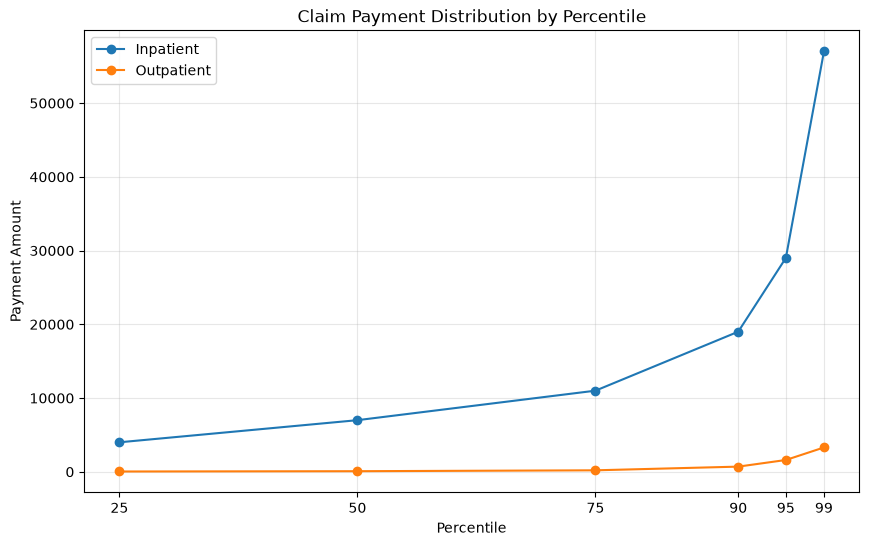

In [8]:
# --------------------------------------------------
# EDA 5: Payment Distribution Visualization
# --------------------------------------------------

percentile_values = [25, 50, 75, 90, 95, 99]

plt.figure(figsize=(10, 6))

plt.plot(
    percentile_values,
    payment_distribution["Inpatient Payment"],
    marker="o",
    label="Inpatient"
)

plt.plot(
    percentile_values,
    payment_distribution["Outpatient Payment"],
    marker="o",
    label="Outpatient"
)

plt.title("Claim Payment Distribution by Percentile")
plt.xlabel("Percentile")
plt.ylabel("Payment Amount")
plt.xticks(percentile_values)
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

In [9]:
# --------------------------------------------------
# EDA 6: Payment Status Distribution
# --------------------------------------------------

def payment_status_summary(dataframe, payment_column="CLM_PMT_AMT"):
    payments = pd.to_numeric(
        dataframe[payment_column],
        errors="coerce"
    )

    return pd.Series({
        "Total Claims": len(payments),
        "Positive Payments": (payments > 0).sum(),
        "Zero Payments": (payments == 0).sum(),
        "Negative Payments": (payments < 0).sum(),
        "Missing Payments": payments.isna().sum()
    })


payment_status = pd.DataFrame({
    "Inpatient": payment_status_summary(inpatient),
    "Outpatient": payment_status_summary(outpatient)
}).T

for column in [
    "Positive Payments",
    "Zero Payments",
    "Negative Payments",
    "Missing Payments"
]:
    payment_status[f"{column} (%)"] = (
        payment_status[column]
        / payment_status["Total Claims"]
        * 100
    ).round(2)

display(payment_status)

,Total Claims,Positive Payments,Zero Payments,Negative Payments,Missing Payments,Positive Payments (%),Zero Payments (%),Negative Payments (%),Missing Payments (%)
Inpatient,66773,64558,2160,55,0,96.68,3.23,0.08,0.0
Outpatient,790790,758119,30105,2566,0,95.87,3.81,0.32,0.0


In [10]:
# --------------------------------------------------
# EDA 7: Monthly Inpatient Claims and Payments
# --------------------------------------------------

inpatient_monthly = (
    inpatient
    .assign(
        Claim_Month=pd.to_datetime(
            inpatient["CLM_FROM_DT"],
            errors="coerce"
        ).dt.to_period("M").astype("string")
    )
    .groupby("Claim_Month", dropna=False)
    .agg(
        Claims=("CLM_ID", "count"),
        Total_Payments=("CLM_PMT_AMT", "sum")
    )
    .reset_index()
)

inpatient_monthly["Total_Payments"] = (
    inpatient_monthly["Total_Payments"]
    .round(2)
)

display(inpatient_monthly)

,Claim_Month,Claims,Total_Payments
0,2007-11,2,65000.0
1,2007-12,222,2705000.0
2,2008-01,1535,14510480.0
3,2008-02,1804,16260110.0
4,2008-03,2301,20918530.0
5,2008-04,2315,21652870.0
6,2008-05,2587,24263340.0
7,2008-06,2453,23039910.0
8,2008-07,2470,22948390.0
9,2008-08,2586,23900310.0


In [11]:
# --------------------------------------------------
# EDA 8: Monthly Outpatient Claims and Payments
# --------------------------------------------------

outpatient_monthly = (
    outpatient
    .assign(
        Claim_Month=pd.to_datetime(
            outpatient["CLM_FROM_DT"],
            errors="coerce"
        ).dt.to_period("M").astype("string")
    )
    .groupby("Claim_Month", dropna=False)
    .agg(
        Claims=("CLM_ID", "count"),
        Total_Payments=("CLM_PMT_AMT", "sum")
    )
    .reset_index()
)

outpatient_monthly["Total_Payments"] = (
    outpatient_monthly["Total_Payments"]
    .round(2)
)

display(outpatient_monthly)

,Claim_Month,Claims,Total_Payments
0,2007-12,312,265120.0
1,2008-01,10256,2808150.0
2,2008-02,15383,4122220.0
3,2008-03,21051,5253850.0
4,2008-04,23164,5980140.0
5,2008-05,24918,6412820.0
6,2008-06,25063,6435770.0
7,2008-07,26414,6701160.0
8,2008-08,27203,6916270.0
9,2008-09,26418,6821910.0


In [12]:
# --------------------------------------------------
# EDA 9: Combined Monthly Claims and Payment Trends
# --------------------------------------------------

monthly_combined = (
    inpatient_monthly
    .merge(
        outpatient_monthly,
        on="Claim_Month",
        how="outer",
        suffixes=("_Inpatient", "_Outpatient")
    )
    .sort_values("Claim_Month")
)

monthly_combined["Total_Claims"] = (
    monthly_combined["Claims_Inpatient"]
    + monthly_combined["Claims_Outpatient"]
)

monthly_combined["Total_Payments"] = (
    monthly_combined["Total_Payments_Inpatient"]
    + monthly_combined["Total_Payments_Outpatient"]
)

display(monthly_combined)

,Claim_Month,Claims_Inpatient,Total_Payments_Inpatient,Claims_Outpatient,Total_Payments_Outpatient,Total_Claims,Total_Payments
0,2007-11,2,65000.0,NaN,NaN,NaN,NaN
1,2007-12,222,2705000.0,312.0,265120.0,534.0,2970120.0
2,2008-01,1535,14510480.0,10256.0,2808150.0,11791.0,17318630.0
3,2008-02,1804,16260110.0,15383.0,4122220.0,17187.0,20382330.0
4,2008-03,2301,20918530.0,21051.0,5253850.0,23352.0,26172380.0
5,2008-04,2315,21652870.0,23164.0,5980140.0,25479.0,27633010.0
6,2008-05,2587,24263340.0,24918.0,6412820.0,27505.0,30676160.0
7,2008-06,2453,23039910.0,25063.0,6435770.0,27516.0,29475680.0
8,2008-07,2470,22948390.0,26414.0,6701160.0,28884.0,29649550.0
9,2008-08,2586,23900310.0,27203.0,6916270.0,29789.0,30816580.0


In [13]:
# --------------------------------------------------
# EDA 9: Combined Monthly Claims and Payment Trends
# --------------------------------------------------

monthly_combined = (
    inpatient_monthly
    .merge(
        outpatient_monthly,
        on="Claim_Month",
        how="outer",
        suffixes=("_Inpatient", "_Outpatient")
    )
    .sort_values("Claim_Month")
    .reset_index(drop=True)
)

# A missing value means that claim type had no records
# for that month, not that the payment/claim count was missing.
monthly_combined["Claims_Inpatient"] = (
    monthly_combined["Claims_Inpatient"]
    .fillna(0)
)

monthly_combined["Claims_Outpatient"] = (
    monthly_combined["Claims_Outpatient"]
    .fillna(0)
)

monthly_combined["Total_Payments_Inpatient"] = (
    monthly_combined["Total_Payments_Inpatient"]
    .fillna(0)
)

monthly_combined["Total_Payments_Outpatient"] = (
    monthly_combined["Total_Payments_Outpatient"]
    .fillna(0)
)

monthly_combined["Total_Claims"] = (
    monthly_combined["Claims_Inpatient"]
    + monthly_combined["Claims_Outpatient"]
)

monthly_combined["Total_Payments"] = (
    monthly_combined["Total_Payments_Inpatient"]
    + monthly_combined["Total_Payments_Outpatient"]
)

display(monthly_combined)

,Claim_Month,Claims_Inpatient,Total_Payments_Inpatient,Claims_Outpatient,Total_Payments_Outpatient,Total_Claims,Total_Payments
0,2007-11,2,65000.0,0.0,0.0,2.0,65000.0
1,2007-12,222,2705000.0,312.0,265120.0,534.0,2970120.0
2,2008-01,1535,14510480.0,10256.0,2808150.0,11791.0,17318630.0
3,2008-02,1804,16260110.0,15383.0,4122220.0,17187.0,20382330.0
4,2008-03,2301,20918530.0,21051.0,5253850.0,23352.0,26172380.0
5,2008-04,2315,21652870.0,23164.0,5980140.0,25479.0,27633010.0
6,2008-05,2587,24263340.0,24918.0,6412820.0,27505.0,30676160.0
7,2008-06,2453,23039910.0,25063.0,6435770.0,27516.0,29475680.0
8,2008-07,2470,22948390.0,26414.0,6701160.0,28884.0,29649550.0
9,2008-08,2586,23900310.0,27203.0,6916270.0,29789.0,30816580.0


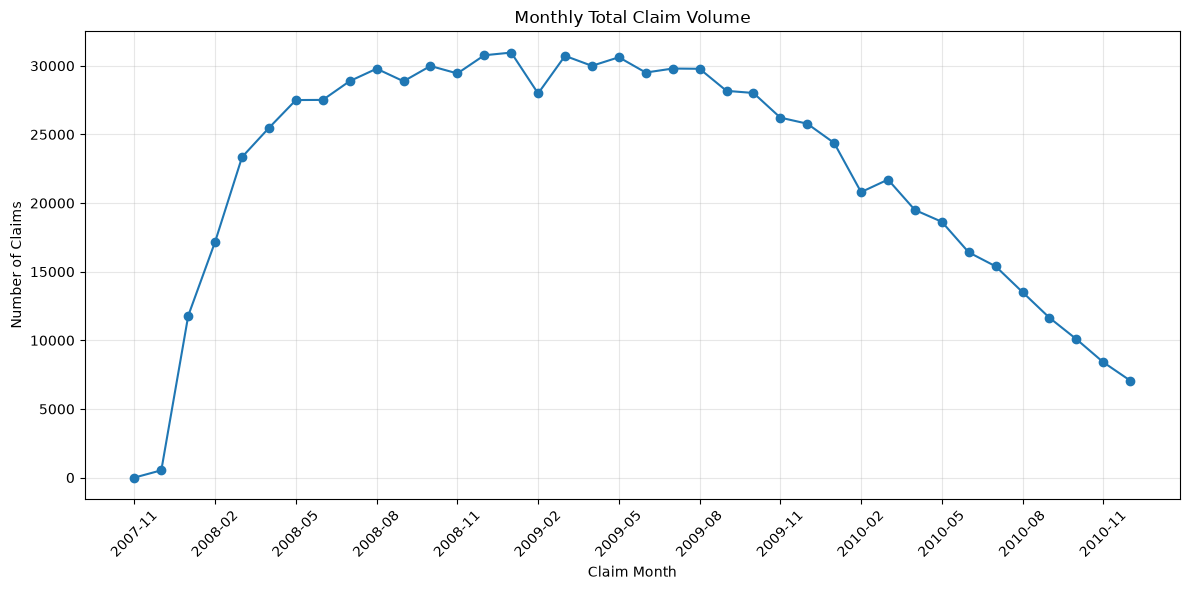

In [14]:
# --------------------------------------------------
# EDA 10: Monthly Total Claim Volume Trend
# --------------------------------------------------

monthly_for_chart = monthly_combined[
    monthly_combined["Claim_Month"].notna()
].copy()

plt.figure(figsize=(12, 6))

plt.plot(
    monthly_for_chart["Claim_Month"],
    monthly_for_chart["Total_Claims"],
    marker="o"
)

plt.title("Monthly Total Claim Volume")
plt.xlabel("Claim Month")
plt.ylabel("Number of Claims")

plt.xticks(
    ticks=range(
        0,
        len(monthly_for_chart),
        3
    ),
    labels=monthly_for_chart["Claim_Month"].iloc[::3],
    rotation=45
)

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [15]:
# --------------------------------------------------
# EDA 11: Top Inpatient Providers by Claim Volume
# --------------------------------------------------

inpatient_provider_summary = (
    inpatient
    .groupby("PRVDR_NUM", dropna=False)
    .agg(
        Claims=("CLM_ID", "count"),
        Total_Payments=("CLM_PMT_AMT", "sum"),
        Average_Payment=("CLM_PMT_AMT", "mean")
    )
    .reset_index()
    .sort_values(
        "Claims",
        ascending=False
    )
)

inpatient_provider_summary[
    ["Total_Payments", "Average_Payment"]
] = (
    inpatient_provider_summary[
        ["Total_Payments", "Average_Payment"]
    ].round(2)
)

top_inpatient_providers = (
    inpatient_provider_summary
    .head(10)
    .reset_index(drop=True)
)

display(top_inpatient_providers)

,PRVDR_NUM,Claims,Total_Payments,Average_Payment
0,23006G,772,7280500.0,9430.70
1,1000AH,634,6116900.0,9648.11
2,3600NG,537,5645000.0,10512.10
3,1401RR,431,3859280.0,8954.25
4,2600ZT,422,3919890.0,9288.84
5,2100WC,400,4046000.0,10115.00
6,3400XN,396,3841000.0,9699.49
7,0501MA,359,3718000.0,10356.55
8,4500DP,337,3315800.0,9839.17
9,1002DC,325,3255400.0,10016.62


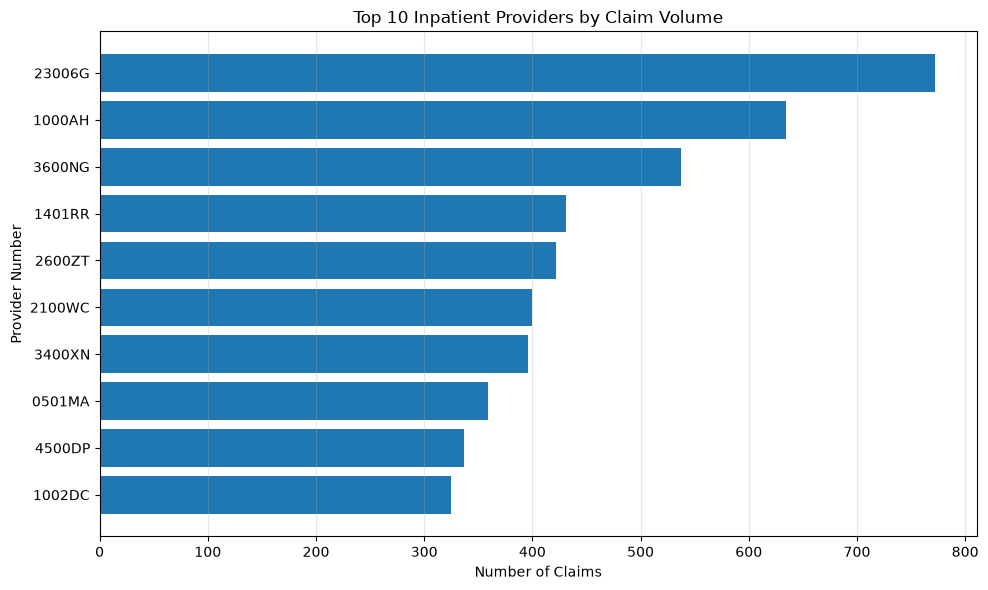

In [16]:
# --------------------------------------------------
# EDA 12: Top Inpatient Providers by Claim Volume
# --------------------------------------------------

plt.figure(figsize=(10, 6))

plt.barh(
    top_inpatient_providers["PRVDR_NUM"].astype(str),
    top_inpatient_providers["Claims"]
)

plt.title("Top 10 Inpatient Providers by Claim Volume")
plt.xlabel("Number of Claims")
plt.ylabel("Provider Number")

plt.gca().invert_yaxis()

plt.grid(
    axis="x",
    alpha=0.3
)

plt.tight_layout()
plt.show()

In [17]:
# --------------------------------------------------
# EDA 13: Top Inpatient Providers by Total Payments
# --------------------------------------------------

top_inpatient_providers_by_payment = (
    inpatient_provider_summary
    .sort_values(
        "Total_Payments",
        ascending=False
    )
    .head(10)
    .reset_index(drop=True)
)

display(top_inpatient_providers_by_payment)

,PRVDR_NUM,Claims,Total_Payments,Average_Payment
0,23006G,772,7280500.0,9430.70
1,1000AH,634,6116900.0,9648.11
2,3600NG,537,5645000.0,10512.10
3,2100WC,400,4046000.0,10115.00
4,2600ZT,422,3919890.0,9288.84
5,1401RR,431,3859280.0,8954.25
6,3400XN,396,3841000.0,9699.49
7,0501MA,359,3718000.0,10356.55
8,3100JN,315,3567600.0,11325.71
9,4500DP,337,3315800.0,9839.17


In [18]:
# --------------------------------------------------
# EDA 14: Providers by Average Inpatient Payment
# --------------------------------------------------

provider_average_payment = (
    inpatient_provider_summary[
        inpatient_provider_summary["Claims"] >= 50
    ]
    .sort_values(
        "Average_Payment",
        ascending=False
    )
    .head(10)
    .reset_index(drop=True)
)

display(provider_average_payment)

,PRVDR_NUM,Claims,Total_Payments,Average_Payment
0,1500KD,57,816000.0,14315.79
1,3600VA,50,668000.0,13360.00
2,3100GR,56,727000.0,12982.14
3,10S0NQ,52,657000.0,12634.62
4,33038A,73,885600.0,12131.51
5,0600PR,79,955000.0,12088.61
6,0506TS,55,650000.0,11818.18
7,67006C,58,683000.0,11775.86
8,2801QQ,62,727000.0,11725.81
9,3302VG,210,2444600.0,11640.95


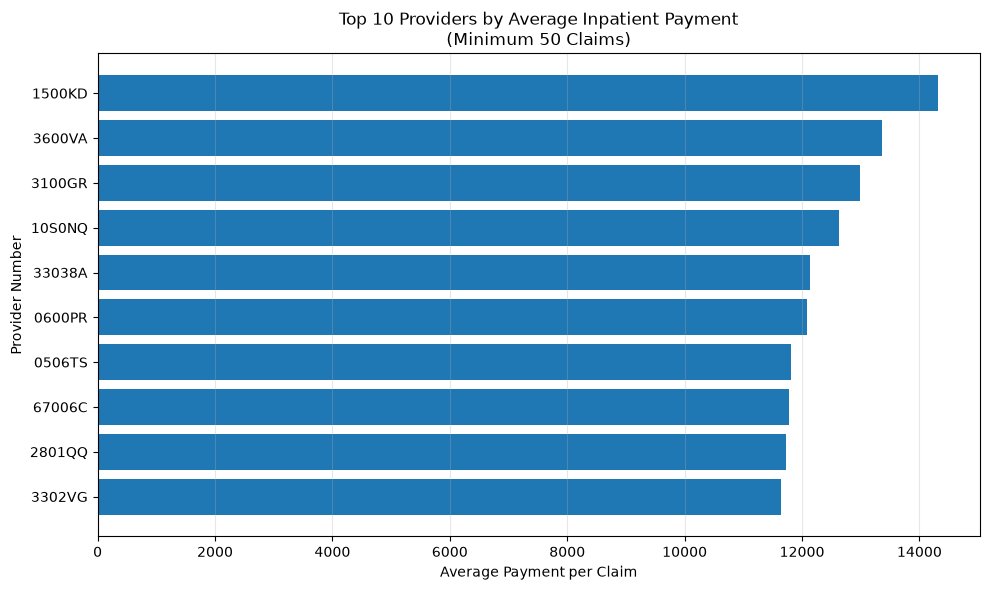

In [19]:
# --------------------------------------------------
# EDA 15: Providers with Highest Average Inpatient Payment
# --------------------------------------------------

plt.figure(figsize=(10, 6))

plt.barh(
    provider_average_payment["PRVDR_NUM"].astype(str),
    provider_average_payment["Average_Payment"]
)

plt.title(
    "Top 10 Providers by Average Inpatient Payment\n"
    "(Minimum 50 Claims)"
)

plt.xlabel("Average Payment per Claim")
plt.ylabel("Provider Number")

plt.gca().invert_yaxis()

plt.grid(
    axis="x",
    alpha=0.3
)

plt.tight_layout()
plt.show()

In [20]:
# --------------------------------------------------
# EDA 16: Claims per Beneficiary
# --------------------------------------------------

inpatient_beneficiary_claims = (
    inpatient
    .groupby("DESYNPUF_ID")
    .size()
    .rename("Inpatient_Claims")
)

outpatient_beneficiary_claims = (
    outpatient
    .groupby("DESYNPUF_ID")
    .size()
    .rename("Outpatient_Claims")
)

beneficiary_utilization = pd.concat(
    [
        inpatient_beneficiary_claims,
        outpatient_beneficiary_claims
    ],
    axis=1
).fillna(0)

beneficiary_utilization["Total_Claims"] = (
    beneficiary_utilization["Inpatient_Claims"]
    + beneficiary_utilization["Outpatient_Claims"]
)

beneficiary_utilization = (
    beneficiary_utilization
    .reset_index()
    .sort_values(
        "Total_Claims",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    beneficiary_utilization.head(10)
)

,DESYNPUF_ID,Inpatient_Claims,Outpatient_Claims,Total_Claims
0,AD5D4E087BF57C05,1.0,78.0,79.0
1,14D1519892CEDDD0,2.0,73.0,75.0
2,6688888FAE4A668D,2.0,73.0,75.0
3,CFD2F732F669EC76,2.0,69.0,71.0
4,5E3E22BC2E5B89E3,2.0,69.0,71.0
5,33415D5D1E294286,1.0,67.0,68.0
6,1B2D14B2CB66232D,4.0,64.0,68.0
7,B46578660601458F,0.0,68.0,68.0
8,2C836F251F047E06,3.0,65.0,68.0
9,96376191B64808AB,5.0,62.0,67.0


In [21]:
# --------------------------------------------------
# EDA 17: Standardize Beneficiary Claim Counts
# --------------------------------------------------

claim_count_columns = [
    "Inpatient_Claims",
    "Outpatient_Claims",
    "Total_Claims"
]

beneficiary_utilization[claim_count_columns] = (
    beneficiary_utilization[claim_count_columns]
    .astype(int)
)

display(
    beneficiary_utilization.head(10)
)

,DESYNPUF_ID,Inpatient_Claims,Outpatient_Claims,Total_Claims
0,AD5D4E087BF57C05,1,78,79
1,14D1519892CEDDD0,2,73,75
2,6688888FAE4A668D,2,73,75
3,CFD2F732F669EC76,2,69,71
4,5E3E22BC2E5B89E3,2,69,71
5,33415D5D1E294286,1,67,68
6,1B2D14B2CB66232D,4,64,68
7,B46578660601458F,0,68,68
8,2C836F251F047E06,3,65,68
9,96376191B64808AB,5,62,67


In [22]:
# --------------------------------------------------
# EDA 18: Beneficiary Utilization Distribution
# --------------------------------------------------

utilization_distribution = (
    beneficiary_utilization["Total_Claims"]
    .describe(
        percentiles=[
            0.50,
            0.75,
            0.90,
            0.95,
            0.99
        ]
    )
    .round(2)
)

display(utilization_distribution)

count    86738.00
mean         9.89
std          8.70
min          1.00
50%          8.00
75%         14.00
90%         22.00
95%         27.00
99%         38.00
max         79.00
Name: Total_Claims, dtype: float64

In [23]:
# --------------------------------------------------
# EDA 19: High-Utilization Beneficiaries
# --------------------------------------------------

high_utilization_threshold = (
    beneficiary_utilization["Total_Claims"]
    .quantile(0.95)
)

high_utilization_threshold = int(
    np.ceil(high_utilization_threshold)
)

high_utilization_beneficiaries = (
    beneficiary_utilization[
        beneficiary_utilization["Total_Claims"]
        >= high_utilization_threshold
    ]
    .copy()
)

high_utilization_summary = pd.DataFrame({
    "Metric": [
        "High-utilization threshold",
        "High-utilization beneficiaries",
        "Total beneficiaries with claims",
        "Percentage of beneficiaries"
    ],
    "Value": [
        high_utilization_threshold,
        len(high_utilization_beneficiaries),
        len(beneficiary_utilization),
        round(
            len(high_utilization_beneficiaries)
            / len(beneficiary_utilization)
            * 100,
            2
        )
    ]
})

display(high_utilization_summary)

print("\nTop high-utilization beneficiaries:")
display(
    high_utilization_beneficiaries.head(10)
)

,Metric,Value
0,High-utilization threshold,27.00
1,High-utilization beneficiaries,4730.00
2,Total beneficiaries with claims,86738.00
3,Percentage of beneficiaries,5.45



Top high-utilization beneficiaries:


,DESYNPUF_ID,Inpatient_Claims,Outpatient_Claims,Total_Claims
0,AD5D4E087BF57C05,1,78,79
1,14D1519892CEDDD0,2,73,75
2,6688888FAE4A668D,2,73,75
3,CFD2F732F669EC76,2,69,71
4,5E3E22BC2E5B89E3,2,69,71
5,33415D5D1E294286,1,67,68
6,1B2D14B2CB66232D,4,64,68
7,B46578660601458F,0,68,68
8,2C836F251F047E06,3,65,68
9,96376191B64808AB,5,62,67


In [24]:
# --------------------------------------------------
# EDA 20: Format High-Utilization Summary
# --------------------------------------------------

high_utilization_summary["Value"] = (
    high_utilization_summary["Value"]
    .astype(float)
)

high_utilization_summary.loc[
    high_utilization_summary["Metric"]
    .isin([
        "High-utilization threshold",
        "High-utilization beneficiaries",
        "Total beneficiaries with claims"
    ]),
    "Value"
] = (
    high_utilization_summary.loc[
        high_utilization_summary["Metric"]
        .isin([
            "High-utilization threshold",
            "High-utilization beneficiaries",
            "Total beneficiaries with claims"
        ]),
        "Value"
    ]
    .round(0)
    .astype(int)
)

display(high_utilization_summary)

,Metric,Value
0,High-utilization threshold,27.00
1,High-utilization beneficiaries,4730.00
2,Total beneficiaries with claims,86738.00
3,Percentage of beneficiaries,5.45


In [25]:
# --------------------------------------------------
# EDA 21: High-Utilization Beneficiaries by Claim Type
# --------------------------------------------------

high_utilization_claim_mix = pd.DataFrame({
    "Claim Type": [
        "Inpatient",
        "Outpatient"
    ],
    "Total Claims": [
        high_utilization_beneficiaries["Inpatient_Claims"].sum(),
        high_utilization_beneficiaries["Outpatient_Claims"].sum()
    ]
})

high_utilization_claim_mix["Share (%)"] = (
    high_utilization_claim_mix["Total Claims"]
    / high_utilization_claim_mix["Total Claims"].sum()
    * 100
).round(2)

display(high_utilization_claim_mix)

,Claim Type,Total Claims,Share (%)
0,Inpatient,10924,6.94
1,Outpatient,146450,93.06


In [26]:
# --------------------------------------------------
# EDA 22: Payments Associated with High-Utilization
# Beneficiaries
# --------------------------------------------------

high_utilization_ids = set(
    high_utilization_beneficiaries["DESYNPUF_ID"]
)

high_utilization_inpatient = inpatient[
    inpatient["DESYNPUF_ID"].isin(high_utilization_ids)
].copy()

high_utilization_outpatient = outpatient[
    outpatient["DESYNPUF_ID"].isin(high_utilization_ids)
].copy()

high_utilization_payment_summary = pd.DataFrame({
    "Claim Type": [
        "Inpatient",
        "Outpatient"
    ],
    "Claims": [
        len(high_utilization_inpatient),
        len(high_utilization_outpatient)
    ],
    "Total Payments": [
        high_utilization_inpatient["CLM_PMT_AMT"].sum(),
        high_utilization_outpatient["CLM_PMT_AMT"].sum()
    ],
    "Average Payment": [
        high_utilization_inpatient["CLM_PMT_AMT"].mean(),
        high_utilization_outpatient["CLM_PMT_AMT"].mean()
    ]
})

high_utilization_payment_summary[
    ["Total Payments", "Average Payment"]
] = (
    high_utilization_payment_summary[
        ["Total Payments", "Average Payment"]
    ].round(2)
)

display(high_utilization_payment_summary)

,Claim Type,Claims,Total Payments,Average Payment
0,Inpatient,10924,107297340.0,9822.17
1,Outpatient,146450,72571980.0,495.54


In [27]:
# --------------------------------------------------
# EDA 23: Top Inpatient Primary Diagnoses
# --------------------------------------------------

inpatient_primary_diagnosis = (
    inpatient["ICD9_DGNS_CD_1"]
    .dropna()
    .astype("string")
    .str.strip()
)

top_inpatient_diagnoses = (
    inpatient_primary_diagnosis
    .value_counts()
    .head(20)
    .rename_axis("Diagnosis_Code")
    .reset_index(name="Claims")
)

top_inpatient_diagnoses["Share (%)"] = (
    top_inpatient_diagnoses["Claims"]
    / len(inpatient_primary_diagnosis)
    * 100
).round(2)

display(top_inpatient_diagnoses)

,Diagnosis_Code,Claims,Share (%)
0,486,2453,3.68
1,V5789,1807,2.71
2,41401,1675,2.51
3,0389,1648,2.47
4,49121,1558,2.34
5,4280,1419,2.13
6,5990,1374,2.06
7,42731,1253,1.88
8,41071,1170,1.75
9,71536,1154,1.73


In [28]:
# --------------------------------------------------
# EDA 24: Inpatient Diagnoses by Total Payments
# --------------------------------------------------

inpatient_diagnosis_payment = (
    inpatient[
        ["ICD9_DGNS_CD_1", "CLM_PMT_AMT"]
    ]
    .dropna(subset=["ICD9_DGNS_CD_1"])
    .groupby("ICD9_DGNS_CD_1")
    .agg(
        Claims=("CLM_PMT_AMT", "count"),
        Total_Payments=("CLM_PMT_AMT", "sum"),
        Average_Payment=("CLM_PMT_AMT", "mean")
    )
    .reset_index()
    .sort_values(
        "Total_Payments",
        ascending=False
    )
    .head(20)
    .reset_index(drop=True)
)

inpatient_diagnosis_payment[
    ["Total_Payments", "Average_Payment"]
] = (
    inpatient_diagnosis_payment[
        ["Total_Payments", "Average_Payment"]
    ]
    .round(2)
)

display(inpatient_diagnosis_payment)

,ICD9_DGNS_CD_1,Claims,Total_Payments,Average_Payment
0,V5789,1807,28421550.0,15728.58
1,0389,1648,24408390.0,14810.92
2,41401,1675,23847800.0,14237.49
3,486,2453,17101860.0,6971.81
4,41071,1170,14809630.0,12657.80
5,51881,817,14232900.0,17420.93
6,71536,1154,13133020.0,11380.43
7,4280,1419,11069900.0,7801.20
8,49121,1558,9999100.0,6417.91
9,5070,705,8624900.0,12233.90


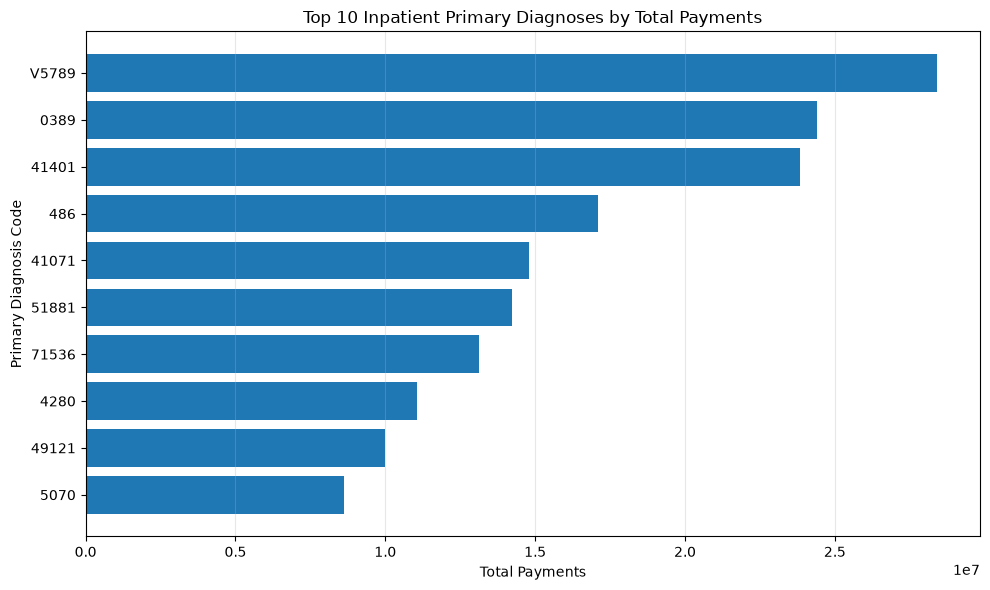

In [29]:
# --------------------------------------------------
# EDA 25: Top Inpatient Diagnoses by Total Payments
# --------------------------------------------------

top_diagnosis_payment_chart = (
    inpatient_diagnosis_payment
    .head(10)
    .sort_values(
        "Total_Payments",
        ascending=True
    )
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_diagnosis_payment_chart["ICD9_DGNS_CD_1"].astype(str),
    top_diagnosis_payment_chart["Total_Payments"]
)

plt.title(
    "Top 10 Inpatient Primary Diagnoses by Total Payments"
)

plt.xlabel("Total Payments")
plt.ylabel("Primary Diagnosis Code")

plt.grid(
    axis="x",
    alpha=0.3
)

plt.tight_layout()
plt.show()

In [30]:
# --------------------------------------------------
# EDA 26: Top Inpatient Primary Procedure Codes
# --------------------------------------------------

inpatient_primary_procedure = (
    inpatient["ICD9_PRCDR_CD_1"]
    .dropna()
    .astype("string")
    .str.strip()
)

top_inpatient_procedures = (
    inpatient_primary_procedure
    .value_counts()
    .head(20)
    .rename_axis("Procedure_Code")
    .reset_index(name="Claims")
)

top_inpatient_procedures["Share (%)"] = (
    top_inpatient_procedures["Claims"]
    / len(inpatient_primary_procedure)
    * 100
).round(2)

display(top_inpatient_procedures)

,Procedure_Code,Claims,Share (%)
0,9904.0,1861,4.87
1,8154.0,1646,4.31
2,3893.0,1424,3.72
3,66.0,1401,3.66
4,3995.0,1284,3.36
5,4516.0,1049,2.74
6,3722.0,982,2.57
7,8872.0,708,1.85
8,9671.0,707,1.85
9,8151.0,678,1.77


In [31]:
# --------------------------------------------------
# EDA 27: Standardize Inpatient Procedure Code Display
# --------------------------------------------------

top_inpatient_procedures["Procedure_Code"] = (
    top_inpatient_procedures["Procedure_Code"]
    .astype("string")
    .str.replace(r"\.0$", "", regex=True)
)

display(top_inpatient_procedures)

,Procedure_Code,Claims,Share (%)
0,9904,1861,4.87
1,8154,1646,4.31
2,3893,1424,3.72
3,66,1401,3.66
4,3995,1284,3.36
5,4516,1049,2.74
6,3722,982,2.57
7,8872,708,1.85
8,9671,707,1.85
9,8151,678,1.77


In [32]:
# --------------------------------------------------
# EDA 28: Top Outpatient HCPCS Codes
# --------------------------------------------------

outpatient_hcpcs = (
    outpatient["HCPCS_CD_1"]
    .dropna()
    .astype("string")
    .str.strip()
)

top_outpatient_hcpcs = (
    outpatient_hcpcs
    .value_counts()
    .head(20)
    .rename_axis("HCPCS_Code")
    .reset_index(name="Claims")
)

top_outpatient_hcpcs["Share (%)"] = (
    top_outpatient_hcpcs["Claims"]
    / len(outpatient_hcpcs)
    * 100
).round(2)

display(top_outpatient_hcpcs)

,HCPCS_Code,Claims,Share (%)
0,36415,161373,24.97
1,99213,31792,4.92
2,99212,23658,3.66
3,80053,22883,3.54
4,A4657,20237,3.13
5,85610,19812,3.07
6,97110,18410,2.85
7,99214,14890,2.3
8,80048,13866,2.15
9,G0202,13462,2.08


In [33]:
# --------------------------------------------------
# EDA 29: Outpatient HCPCS Codes by Total Payments
# --------------------------------------------------

outpatient_hcpcs_payment = (
    outpatient[
        ["HCPCS_CD_1", "CLM_PMT_AMT"]
    ]
    .dropna(subset=["HCPCS_CD_1"])
    .groupby("HCPCS_CD_1")
    .agg(
        Claims=("CLM_PMT_AMT", "count"),
        Total_Payments=("CLM_PMT_AMT", "sum"),
        Average_Payment=("CLM_PMT_AMT", "mean")
    )
    .reset_index()
    .sort_values(
        "Total_Payments",
        ascending=False
    )
    .head(20)
    .reset_index(drop=True)
)

outpatient_hcpcs_payment[
    ["Total_Payments", "Average_Payment"]
] = (
    outpatient_hcpcs_payment[
        ["Total_Payments", "Average_Payment"]
    ]
    .round(2)
)

display(outpatient_hcpcs_payment)

,HCPCS_CD_1,Claims,Total_Payments,Average_Payment
0,A4657,20237,38757960.0,1915.20
1,36415,161373,26543690.0,164.49
2,97110,18410,6164830.0,334.86
3,99213,31792,5918100.0,186.15
4,99212,23658,4448470.0,188.03
5,80053,22883,4358430.0,190.47
6,99214,14890,2878340.0,193.31
7,99211,11512,2715300.0,235.87
8,80048,13866,2612220.0,188.39
9,71020,12244,2502580.0,204.39


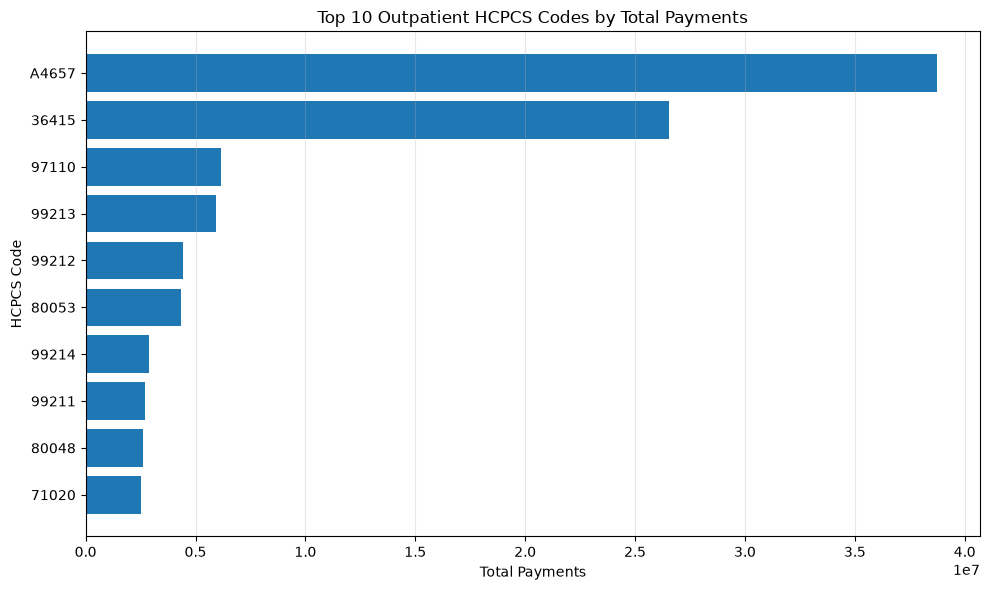

In [34]:
# --------------------------------------------------
# EDA 30: Top 10 Outpatient HCPCS Codes by Payments
# --------------------------------------------------

top_hcpcs_payment_chart = (
    outpatient_hcpcs_payment
    .head(10)
    .sort_values(
        "Total_Payments",
        ascending=True
    )
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_hcpcs_payment_chart["HCPCS_CD_1"].astype(str),
    top_hcpcs_payment_chart["Total_Payments"]
)

plt.title(
    "Top 10 Outpatient HCPCS Codes by Total Payments"
)

plt.xlabel("Total Payments")
plt.ylabel("HCPCS Code")

plt.grid(
    axis="x",
    alpha=0.3
)

plt.tight_layout()
plt.show()

In [35]:
# --------------------------------------------------
# EDA 31: Inpatient Length of Stay Distribution
# --------------------------------------------------

inpatient_los = (
    pd.to_numeric(
        inpatient["CLM_UTLZTN_DAY_CNT"],
        errors="coerce"
    )
)

los_summary = (
    inpatient_los
    .describe(
        percentiles=[
            0.50,
            0.75,
            0.90,
            0.95,
            0.99
        ]
    )
    .round(2)
)

display(los_summary)

count    66705.00
mean         5.58
std          6.28
min          0.00
50%          4.00
75%          7.00
90%         12.00
95%         16.00
99%         31.00
max        136.00
Name: CLM_UTLZTN_DAY_CNT, dtype: float64

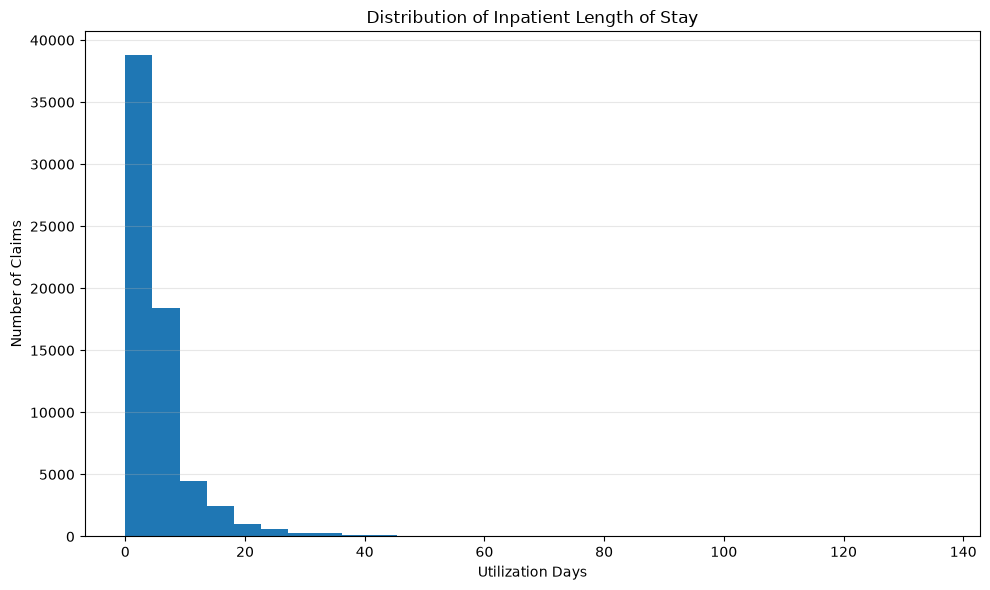

In [36]:
# --------------------------------------------------
# EDA 32: Inpatient Length of Stay Distribution Chart
# --------------------------------------------------

los_for_chart = inpatient_los.dropna()

plt.figure(figsize=(10, 6))

plt.hist(
    los_for_chart,
    bins=30
)

plt.title(
    "Distribution of Inpatient Length of Stay"
)

plt.xlabel("Utilization Days")
plt.ylabel("Number of Claims")

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()

In [37]:
# --------------------------------------------------
# EDA 33: Length of Stay vs Average Claim Payment
# --------------------------------------------------

los_payment_data = inpatient[
    ["CLM_UTLZTN_DAY_CNT", "CLM_PMT_AMT"]
].copy()

los_payment_data["LOS_Days"] = pd.to_numeric(
    los_payment_data["CLM_UTLZTN_DAY_CNT"],
    errors="coerce"
)

los_payment_data["Payment"] = pd.to_numeric(
    los_payment_data["CLM_PMT_AMT"],
    errors="coerce"
)

los_payment_data = los_payment_data.dropna(
    subset=["LOS_Days", "Payment"]
)

los_payment_data["LOS_Band"] = pd.cut(
    los_payment_data["LOS_Days"],
    bins=[-1, 0, 3, 7, 14, 30, float("inf")],
    labels=[
        "0 days",
        "1–3 days",
        "4–7 days",
        "8–14 days",
        "15–30 days",
        "31+ days"
    ]
)

los_payment_summary = (
    los_payment_data
    .groupby("LOS_Band", observed=True)
    .agg(
        Claims=("Payment", "count"),
        Total_Payments=("Payment", "sum"),
        Average_Payment=("Payment", "mean"),
        Median_Payment=("Payment", "median")
    )
    .reset_index()
)

los_payment_summary[
    ["Total_Payments", "Average_Payment", "Median_Payment"]
] = (
    los_payment_summary[
        ["Total_Payments", "Average_Payment", "Median_Payment"]
    ]
    .round(2)
)

display(los_payment_summary)

,LOS_Band,Claims,Total_Payments,Average_Payment,Median_Payment
0,0 days,2266,21247220.0,9376.53,6000.0
1,1–3 days,28568,203204610.0,7113.01,5000.0
2,4–7 days,21842,203549480.0,9319.18,7000.0
3,8–14 days,9739,129201800.0,13266.43,10000.0
4,15–30 days,3599,63803070.0,17728.00,13000.0
5,31+ days,691,16976300.0,24567.73,18000.0


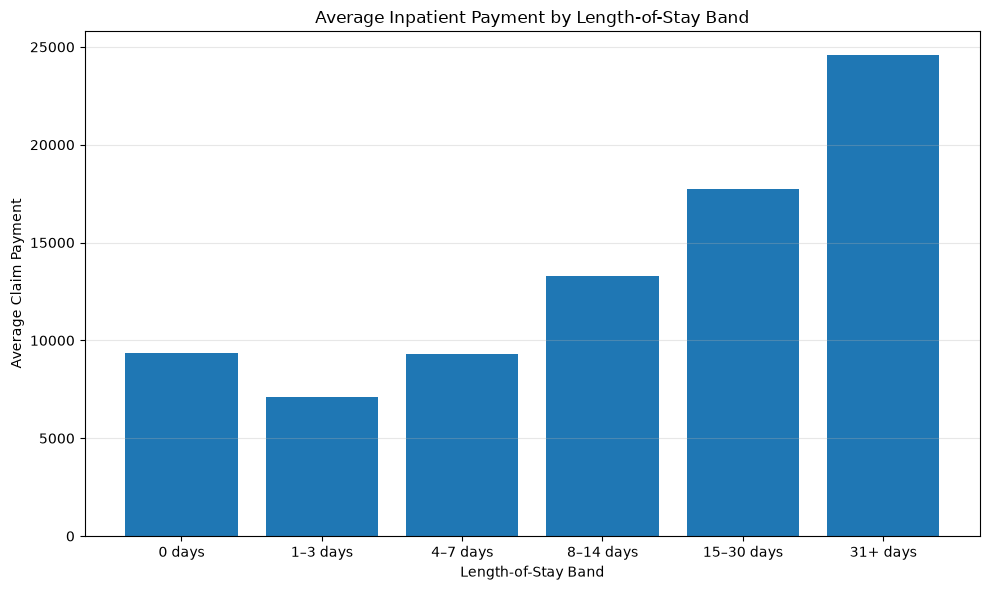

In [38]:
# --------------------------------------------------
# EDA 34: Length of Stay vs Average Payment Chart
# --------------------------------------------------

plt.figure(figsize=(10, 6))

plt.bar(
    los_payment_summary["LOS_Band"].astype(str),
    los_payment_summary["Average_Payment"]
)

plt.title(
    "Average Inpatient Payment by Length-of-Stay Band"
)

plt.xlabel("Length-of-Stay Band")
plt.ylabel("Average Claim Payment")

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()

In [39]:
# --------------------------------------------------
# EDA 35: Negative Payment Analysis
# --------------------------------------------------

negative_inpatient = inpatient[
    inpatient["CLM_PMT_AMT"] < 0
].copy()

negative_outpatient = outpatient[
    outpatient["CLM_PMT_AMT"] < 0
].copy()

negative_payment_summary = pd.DataFrame({
    "Claim Type": [
        "Inpatient",
        "Outpatient"
    ],
    "Negative-Payment Claims": [
        len(negative_inpatient),
        len(negative_outpatient)
    ],
    "Total Negative Payments": [
        negative_inpatient["CLM_PMT_AMT"].sum(),
        negative_outpatient["CLM_PMT_AMT"].sum()
    ],
    "Average Negative Payment": [
        negative_inpatient["CLM_PMT_AMT"].mean(),
        negative_outpatient["CLM_PMT_AMT"].mean()
    ],
    "Minimum Payment": [
        negative_inpatient["CLM_PMT_AMT"].min(),
        negative_outpatient["CLM_PMT_AMT"].min()
    ]
})

negative_payment_summary[
    [
        "Total Negative Payments",
        "Average Negative Payment",
        "Minimum Payment"
    ]
] = (
    negative_payment_summary[
        [
            "Total Negative Payments",
            "Average Negative Payment",
            "Minimum Payment"
        ]
    ]
    .round(2)
)

display(negative_payment_summary)

,Claim Type,Negative-Payment Claims,Total Negative Payments,Average Negative Payment,Minimum Payment
0,Inpatient,55,-33540.0,-609.82,-8000.0
1,Outpatient,2566,-80410.0,-31.34,-100.0


In [40]:
# --------------------------------------------------
# EDA 36: Largest Negative-Payment Claims
# --------------------------------------------------

negative_payment_claims = pd.concat(
    [
        negative_inpatient.assign(
            Claim_Type="Inpatient"
        ),
        negative_outpatient.assign(
            Claim_Type="Outpatient"
        )
    ],
    ignore_index=True
)

largest_negative_payments = (
    negative_payment_claims[
        [
            "Claim_Type",
            "CLM_ID",
            "DESYNPUF_ID",
            "PRVDR_NUM",
            "CLM_FROM_DT",
            "CLM_PMT_AMT"
        ]
    ]
    .sort_values(
        "CLM_PMT_AMT",
        ascending=True
    )
    .head(20)
    .reset_index(drop=True)
)

display(largest_negative_payments)

,Claim_Type,CLM_ID,DESYNPUF_ID,PRVDR_NUM,CLM_FROM_DT,CLM_PMT_AMT
0,Inpatient,196371177023478,C0230CC0BE4043F0,4502NS,2008-12-14,-8000.0
1,Inpatient,196361177003626,19B6ECA664FCC497,3400XN,2008-04-20,-3000.0
2,Inpatient,196261177026268,3616E0473E7F742D,3600TD,2010-07-03,-3000.0
3,Inpatient,196711176991366,08B6E69DF1A8719A,1001HB,2008-04-15,-2000.0
4,Inpatient,196011176988459,FC637951B11FD69B,0502XT,2009-02-11,-2000.0
5,Inpatient,196281177026281,D6ACF3BB7D419C3F,3300JQ,2009-05-04,-2000.0
6,Inpatient,196281177000285,EA81A8046847814A,2600QH,2008-07-27,-1000.0
7,Inpatient,196381177016737,82CBAB91F70CAE5B,4900XD,2008-09-26,-1000.0
8,Inpatient,196681176980989,4B13FC5160B43311,1401RR,2009-05-27,-1000.0
9,Inpatient,196091177009799,8934A2FAEDD4A39B,33T2UU,2008-03-11,-800.0


In [41]:
# --------------------------------------------------
# EDA 37: Zero-Payment Claim Analysis
# --------------------------------------------------

zero_inpatient = inpatient[
    inpatient["CLM_PMT_AMT"] == 0
].copy()

zero_outpatient = outpatient[
    outpatient["CLM_PMT_AMT"] == 0
].copy()

zero_payment_summary = pd.DataFrame({
    "Claim Type": [
        "Inpatient",
        "Outpatient"
    ],
    "Zero-Payment Claims": [
        len(zero_inpatient),
        len(zero_outpatient)
    ],
    "Share of Claims (%)": [
        len(zero_inpatient) / len(inpatient) * 100,
        len(zero_outpatient) / len(outpatient) * 100
    ]
})

zero_payment_summary["Share of Claims (%)"] = (
    zero_payment_summary["Share of Claims (%)"]
    .round(2)
)

display(zero_payment_summary)

,Claim Type,Zero-Payment Claims,Share of Claims (%)
0,Inpatient,2160,3.23
1,Outpatient,30105,3.81


In [42]:
# --------------------------------------------------
# EDA 38: Provider Claim Volume vs Total Payments
# --------------------------------------------------

provider_volume_payment = (
    inpatient
    .groupby("PRVDR_NUM", dropna=False)
    .agg(
        Claims=("CLM_ID", "count"),
        Total_Payments=("CLM_PMT_AMT", "sum")
    )
    .reset_index()
)

provider_volume_payment = (
    provider_volume_payment[
        provider_volume_payment["PRVDR_NUM"].notna()
    ]
    .copy()
)

display(
    provider_volume_payment.head(10)
)

print(
    "\nNumber of inpatient providers:",
    len(provider_volume_payment)
)

,PRVDR_NUM,Claims,Total_Payments
0,01006H,9,166000.0
1,01006V,80,727000.0
2,0100AA,7,83000.0
3,0100AQ,1,4000.0
4,0100BB,14,104000.0
5,0100BK,1,5000.0
6,0100BR,3,7000.0
7,0100CC,1,3000.0
8,0100GP,4,31000.0
9,0100GU,38,388000.0



Number of inpatient providers: 2675


In [43]:
# --------------------------------------------------
# EDA 39: Provider Average Payment per Claim
# --------------------------------------------------

provider_volume_payment["Average_Payment"] = (
    provider_volume_payment["Total_Payments"]
    / provider_volume_payment["Claims"]
).round(2)

provider_average_payment = (
    provider_volume_payment
    .sort_values(
        "Average_Payment",
        ascending=False
    )
    .head(20)
    .reset_index(drop=True)
)

display(provider_average_payment)

,PRVDR_NUM,Claims,Total_Payments,Average_Payment
0,1313CR,1,57000.0,57000.00
1,03T1UA,1,57000.0,57000.00
2,4503CJ,1,57000.0,57000.00
3,1813TB,1,45000.0,45000.00
4,4600GH,1,38000.0,38000.00
5,2413MT,1,35000.0,35000.00
6,4901JG,2,64000.0,32000.00
7,1000MD,1,31000.0,31000.00
8,0100MU,2,61000.0,30500.00
9,3200CM,5,152000.0,30400.00


In [44]:
# --------------------------------------------------
# EDA 40: Provider Average Payment — Minimum Volume
# --------------------------------------------------

provider_average_payment_50plus = (
    provider_volume_payment[
        provider_volume_payment["Claims"] >= 50
    ]
    .sort_values(
        "Average_Payment",
        ascending=False
    )
    .head(20)
    .reset_index(drop=True)
)

display(provider_average_payment_50plus)

print(
    "\nProviders meeting the minimum 50-claim threshold:",
    (provider_volume_payment["Claims"] >= 50).sum()
)

,PRVDR_NUM,Claims,Total_Payments,Average_Payment
0,1500KD,57,816000.0,14315.79
1,3600VA,50,668000.0,13360.00
2,3100GR,56,727000.0,12982.14
3,10S0NQ,52,657000.0,12634.62
4,33038A,73,885600.0,12131.51
5,0600PR,79,955000.0,12088.61
6,0506TS,55,650000.0,11818.18
7,67006C,58,683000.0,11775.86
8,2801QQ,62,727000.0,11725.81
9,3302VG,210,2444600.0,11640.95



Providers meeting the minimum 50-claim threshold: 319


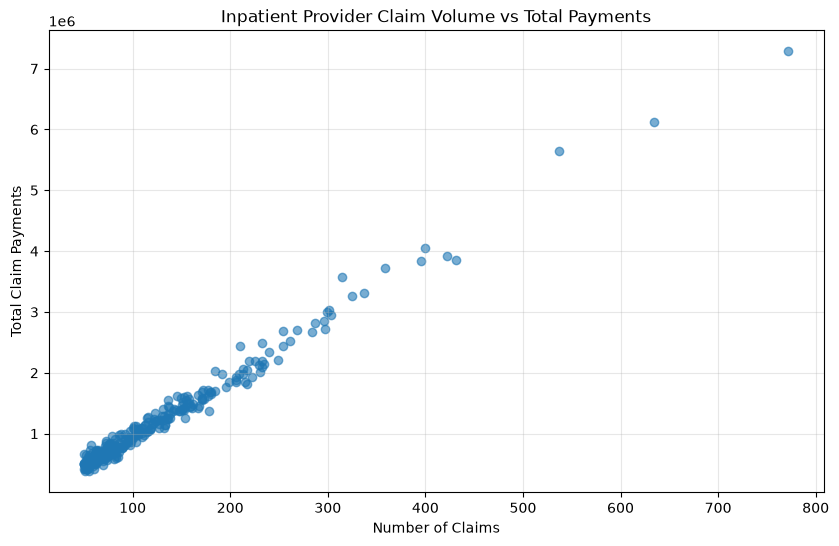

In [45]:
# --------------------------------------------------
# EDA 41: Provider Claim Volume vs Total Payments
# --------------------------------------------------

provider_volume_payment_50plus = (
    provider_volume_payment[
        provider_volume_payment["Claims"] >= 50
    ]
    .copy()
)

plt.figure(figsize=(10, 6))

plt.scatter(
    provider_volume_payment_50plus["Claims"],
    provider_volume_payment_50plus["Total_Payments"],
    alpha=0.6
)

plt.title(
    "Inpatient Provider Claim Volume vs Total Payments"
)
plt.xlabel("Number of Claims")
plt.ylabel("Total Claim Payments")
plt.grid(True, alpha=0.3)

plt.show()

In [46]:
# --------------------------------------------------
# EDA 42: Beneficiary Sex Distribution
# --------------------------------------------------

beneficiary_sex = (
    beneficiary_2008["BENE_SEX_IDENT_CD"]
    .value_counts(dropna=False)
    .rename_axis("Sex_Code")
    .reset_index(name="Beneficiaries")
)

beneficiary_sex["Share (%)"] = (
    beneficiary_sex["Beneficiaries"]
    / beneficiary_sex["Beneficiaries"].sum()
    * 100
).round(2)

display(beneficiary_sex)

print(
    "\nTotal beneficiaries in 2008 file:",
    len(beneficiary_2008)
)

,Sex_Code,Beneficiaries,Share (%)
0,2,64347,55.3
1,1,52005,44.7



Total beneficiaries in 2008 file: 116352


In [47]:
# --------------------------------------------------
# EDA 43: Beneficiary Race Distribution
# --------------------------------------------------

beneficiary_race = (
    beneficiary_2008["BENE_RACE_CD"]
    .value_counts(dropna=False)
    .rename_axis("Race_Code")
    .reset_index(name="Beneficiaries")
)

beneficiary_race["Share (%)"] = (
    beneficiary_race["Beneficiaries"]
    / beneficiary_race["Beneficiaries"].sum()
    * 100
).round(2)

display(beneficiary_race)

print(
    "\nTotal beneficiaries in 2008 file:",
    len(beneficiary_2008)
)

,Race_Code,Beneficiaries,Share (%)
0,1,96349,82.81
1,2,12343,10.61
2,3,4931,4.24
3,5,2729,2.35



Total beneficiaries in 2008 file: 116352


In [48]:
# --------------------------------------------------
# EDA 44: Beneficiary Age Distribution
# --------------------------------------------------

beneficiary_age = beneficiary_2008[
    ["DESYNPUF_ID", "BENE_BIRTH_DT"]
].copy()

beneficiary_age["BENE_BIRTH_DT"] = pd.to_datetime(
    beneficiary_age["BENE_BIRTH_DT"],
    errors="coerce"
)

reference_date = pd.Timestamp("2008-12-31")

beneficiary_age["Age"] = (
    reference_date.year
    - beneficiary_age["BENE_BIRTH_DT"].dt.year
)

# Adjust for birthdays not yet reached by the reference date
birthday_not_reached = (
    (beneficiary_age["BENE_BIRTH_DT"].dt.month > reference_date.month)
    |
    (
        (beneficiary_age["BENE_BIRTH_DT"].dt.month == reference_date.month)
        &
        (beneficiary_age["BENE_BIRTH_DT"].dt.day > reference_date.day)
    )
)

beneficiary_age.loc[birthday_not_reached, "Age"] -= 1

beneficiary_age["Age"] = beneficiary_age["Age"].astype("Int64")

display(
    beneficiary_age["Age"].describe().round(2)
)

print(
    "\nMissing age:",
    beneficiary_age["Age"].isna().sum()
)

count    116352.0
mean        71.65
std          12.5
min          25.0
25%          66.0
50%          72.0
75%          80.0
max          99.0
Name: Age, dtype: Float64


Missing age: 0


In [49]:
# --------------------------------------------------
# EDA 45: Beneficiary Age Bands
# --------------------------------------------------

beneficiary_age["Age_Band"] = pd.cut(
    beneficiary_age["Age"],
    bins=[0, 44, 54, 64, 74, 84, 120],
    labels=[
        "0–44",
        "45–54",
        "55–64",
        "65–74",
        "75–84",
        "85+"
    ],
    right=True
)

age_band_summary = (
    beneficiary_age["Age_Band"]
    .value_counts(sort=False)
    .rename_axis("Age_Band")
    .reset_index(name="Beneficiaries")
)

age_band_summary["Share (%)"] = (
    age_band_summary["Beneficiaries"]
    / age_band_summary["Beneficiaries"].sum()
    * 100
).round(2)

display(age_band_summary)

,Age_Band,Beneficiaries,Share (%)
0,0–44,4486,3.86
1,45–54,5984,5.14
2,55–64,8650,7.43
3,65–74,49547,42.58
4,75–84,32882,28.26
5,85+,14803,12.72


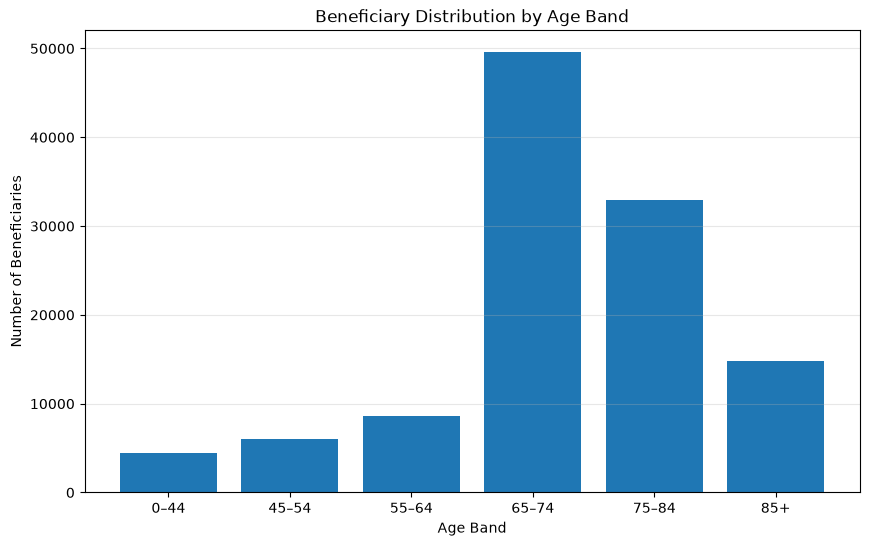

In [50]:
# --------------------------------------------------
# EDA 46: Beneficiary Age Band Visualization
# --------------------------------------------------

plt.figure(figsize=(10, 6))

plt.bar(
    age_band_summary["Age_Band"].astype(str),
    age_band_summary["Beneficiaries"]
)

plt.title("Beneficiary Distribution by Age Band")
plt.xlabel("Age Band")
plt.ylabel("Number of Beneficiaries")
plt.grid(
    axis="y",
    alpha=0.3
)

plt.show()

In [51]:
# --------------------------------------------------
# EDA 47: ESRD Indicator Distribution
# --------------------------------------------------

beneficiary_esrd = (
    beneficiary_2008["BENE_ESRD_IND"]
    .value_counts(dropna=False)
    .rename_axis("ESRD_Code")
    .reset_index(name="Beneficiaries")
)

beneficiary_esrd["Share (%)"] = (
    beneficiary_esrd["Beneficiaries"]
    / beneficiary_esrd["Beneficiaries"].sum()
    * 100
).round(2)

display(beneficiary_esrd)

print(
    "\nTotal beneficiaries in 2008 file:",
    len(beneficiary_2008)
)

,ESRD_Code,Beneficiaries,Share (%)
0,0,108091,92.9
1,Y,8261,7.1



Total beneficiaries in 2008 file: 116352


In [52]:
# --------------------------------------------------
# EDA 48: ESRD Distribution by Age Band
# --------------------------------------------------

beneficiary_esrd_age = beneficiary_age[
    ["DESYNPUF_ID", "Age", "Age_Band"]
].copy()

beneficiary_esrd_age["ESRD_Code"] = (
    beneficiary_2008["BENE_ESRD_IND"]
    .reset_index(drop=True)
)

esrd_by_age = (
    beneficiary_esrd_age
    .groupby(
        ["Age_Band", "ESRD_Code"],
        observed=True
    )
    .size()
    .reset_index(name="Beneficiaries")
)

esrd_by_age["Age_Band_Total"] = (
    esrd_by_age
    .groupby("Age_Band")["Beneficiaries"]
    .transform("sum")
)

esrd_by_age["Share within Age Band (%)"] = (
    esrd_by_age["Beneficiaries"]
    / esrd_by_age["Age_Band_Total"]
    * 100
).round(2)

display(esrd_by_age)

,Age_Band,ESRD_Code,Beneficiaries,Age_Band_Total,Share within Age Band (%)
0,0–44,0,4176,4486,93.09
1,0–44,Y,310,4486,6.91
2,45–54,0,5533,5984,92.46
3,45–54,Y,451,5984,7.54
4,55–64,0,7980,8650,92.25
5,55–64,Y,670,8650,7.75
6,65–74,0,46725,49547,94.30
7,65–74,Y,2822,49547,5.70
8,75–84,0,30243,32882,91.97
9,75–84,Y,2639,32882,8.03


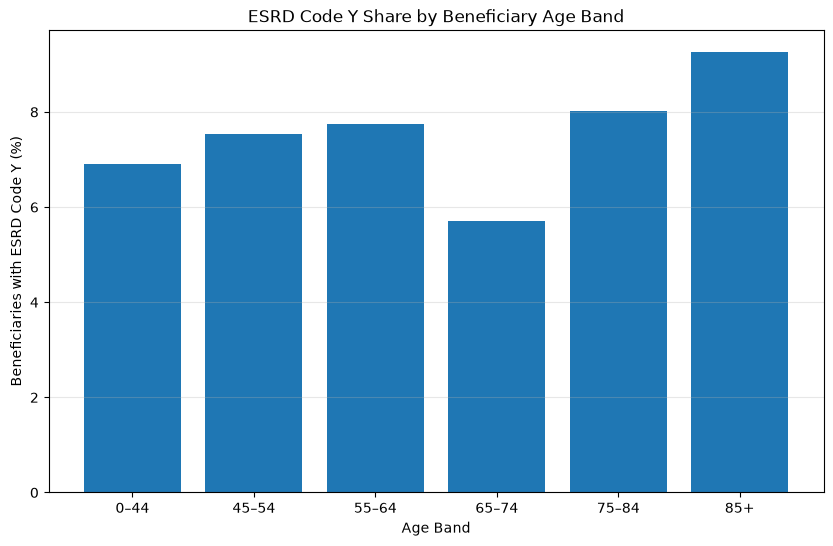

In [53]:
# --------------------------------------------------
# EDA 49: ESRD Share by Age Band Visualization
# --------------------------------------------------

esrd_yes_by_age = (
    esrd_by_age[
        esrd_by_age["ESRD_Code"] == "Y"
    ]
    .copy()
)

plt.figure(figsize=(10, 6))

plt.bar(
    esrd_yes_by_age["Age_Band"].astype(str),
    esrd_yes_by_age["Share within Age Band (%)"]
)

plt.title("ESRD Code Y Share by Beneficiary Age Band")
plt.xlabel("Age Band")
plt.ylabel("Beneficiaries with ESRD Code Y (%)")
plt.grid(
    axis="y",
    alpha=0.3
)

plt.show()

In [54]:
# --------------------------------------------------
# EDA 50: Claims per Beneficiary by Age Band
# --------------------------------------------------

# Inpatient claims per beneficiary
inpatient_counts = (
    inpatient["DESYNPUF_ID"]
    .value_counts()
    .rename("Inpatient_Claims")
)

# Outpatient claims per beneficiary
outpatient_counts = (
    outpatient["DESYNPUF_ID"]
    .value_counts()
    .rename("Outpatient_Claims")
)

# Combine claim counts
beneficiary_utilization = (
    beneficiary_age[
        ["DESYNPUF_ID", "Age_Band"]
    ]
    .copy()
    .set_index("DESYNPUF_ID")
)

beneficiary_utilization = (
    beneficiary_utilization
    .join(inpatient_counts, how="left")
    .join(outpatient_counts, how="left")
    .fillna(0)
)

beneficiary_utilization["Inpatient_Claims"] = (
    beneficiary_utilization["Inpatient_Claims"]
    .astype(int)
)

beneficiary_utilization["Outpatient_Claims"] = (
    beneficiary_utilization["Outpatient_Claims"]
    .astype(int)
)

beneficiary_utilization["Total_Claims"] = (
    beneficiary_utilization["Inpatient_Claims"]
    + beneficiary_utilization["Outpatient_Claims"]
)

age_band_utilization = (
    beneficiary_utilization
    .groupby("Age_Band", observed=True)
    .agg(
        Beneficiaries=("Total_Claims", "size"),
        Beneficiaries_with_Claims=(
            "Total_Claims",
            lambda x: (x > 0).sum()
        ),
        Total_Claims=("Total_Claims", "sum"),
        Average_Claims_per_Beneficiary=(
            "Total_Claims",
            "mean"
        ),
        Median_Claims_per_Beneficiary=(
            "Total_Claims",
            "median"
        )
    )
    .reset_index()
)

age_band_utilization[
    [
        "Average_Claims_per_Beneficiary",
        "Median_Claims_per_Beneficiary"
    ]
] = (
    age_band_utilization[
        [
            "Average_Claims_per_Beneficiary",
            "Median_Claims_per_Beneficiary"
        ]
    ]
    .round(2)
)

display(age_band_utilization)

,Age_Band,Beneficiaries,Beneficiaries_with_Claims,Total_Claims,Average_Claims_per_Beneficiary,Median_Claims_per_Beneficiary
0,0–44,4486,3338,34899,7.78,4.0
1,45–54,5984,4476,47157,7.88,4.0
2,55–64,8650,6434,66401,7.68,4.0
3,65–74,49547,35223,319169,6.44,3.0
4,75–84,32882,25483,261102,7.94,5.0
5,85+,14803,11784,128835,8.70,6.0


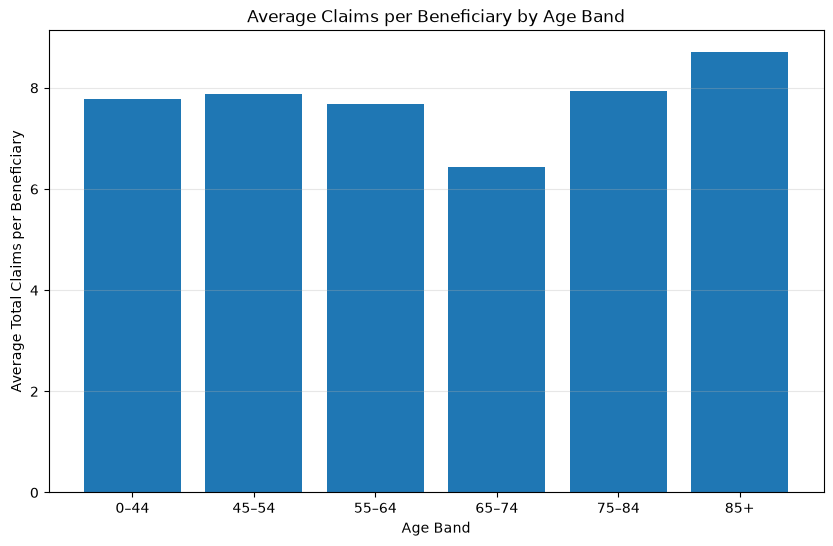

In [55]:
# --------------------------------------------------
# EDA 51: Average Claims per Beneficiary by Age Band
# --------------------------------------------------

plt.figure(figsize=(10, 6))

plt.bar(
    age_band_utilization["Age_Band"].astype(str),
    age_band_utilization["Average_Claims_per_Beneficiary"]
)

plt.title("Average Claims per Beneficiary by Age Band")
plt.xlabel("Age Band")
plt.ylabel("Average Total Claims per Beneficiary")

plt.grid(
    axis="y",
    alpha=0.3
)

plt.show()

In [56]:
# --------------------------------------------------
# EDA 52: Inpatient vs Outpatient Claims by Age Band
# --------------------------------------------------

age_band_claim_type = (
    beneficiary_utilization
    .groupby("Age_Band", observed=True)
    .agg(
        Beneficiaries=("Total_Claims", "size"),
        Inpatient_Claims=("Inpatient_Claims", "sum"),
        Outpatient_Claims=("Outpatient_Claims", "sum")
    )
    .reset_index()
)

age_band_claim_type["Total_Claims"] = (
    age_band_claim_type["Inpatient_Claims"]
    + age_band_claim_type["Outpatient_Claims"]
)

age_band_claim_type["Inpatient_Share (%)"] = (
    age_band_claim_type["Inpatient_Claims"]
    / age_band_claim_type["Total_Claims"]
    * 100
).round(2)

age_band_claim_type["Outpatient_Share (%)"] = (
    age_band_claim_type["Outpatient_Claims"]
    / age_band_claim_type["Total_Claims"]
    * 100
).round(2)

display(age_band_claim_type)

,Age_Band,Beneficiaries,Inpatient_Claims,Outpatient_Claims,Total_Claims,Inpatient_Share (%),Outpatient_Share (%)
0,0–44,4486,2647,32252,34899,7.58,92.42
1,45–54,5984,3563,43594,47157,7.56,92.44
2,55–64,8650,5312,61089,66401,8.00,92.00
3,65–74,49547,22730,296439,319169,7.12,92.88
4,75–84,32882,20900,240202,261102,8.00,92.00
5,85+,14803,11621,117214,128835,9.02,90.98


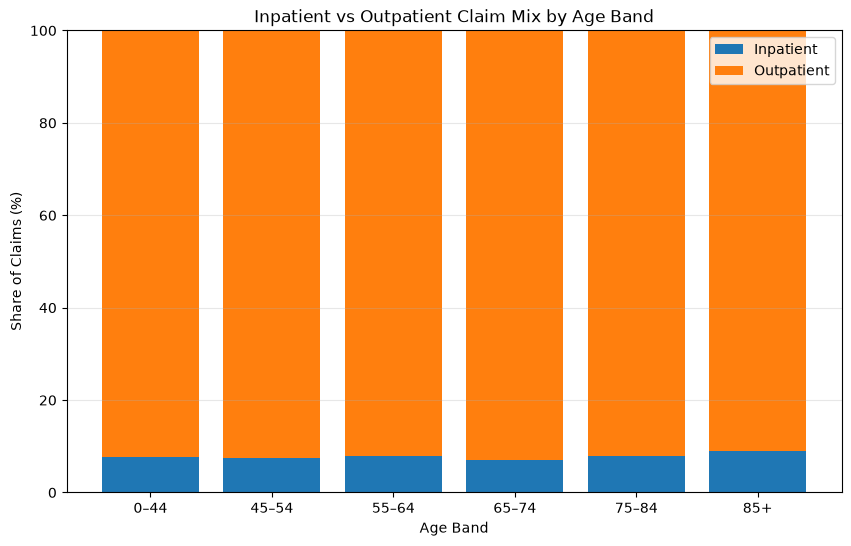

In [57]:
# --------------------------------------------------
# EDA 53: Inpatient vs Outpatient Claim Mix by Age Band
# --------------------------------------------------

plt.figure(figsize=(10, 6))

plt.bar(
    age_band_claim_type["Age_Band"].astype(str),
    age_band_claim_type["Inpatient_Share (%)"],
    label="Inpatient"
)

plt.bar(
    age_band_claim_type["Age_Band"].astype(str),
    age_band_claim_type["Outpatient_Share (%)"],
    bottom=age_band_claim_type["Inpatient_Share (%)"],
    label="Outpatient"
)

plt.title("Inpatient vs Outpatient Claim Mix by Age Band")
plt.xlabel("Age Band")
plt.ylabel("Share of Claims (%)")
plt.ylim(0, 100)
plt.legend()
plt.grid(
    axis="y",
    alpha=0.3
)

plt.show()

In [58]:
# --------------------------------------------------
# EDA 54: Claim Payments by Beneficiary Age Band
# --------------------------------------------------

beneficiary_age_lookup = beneficiary_age[
    ["DESYNPUF_ID", "Age_Band"]
].copy()

# Inpatient payments by age band
inpatient_age_payment = (
    inpatient[
        ["DESYNPUF_ID", "CLM_PMT_AMT"]
    ]
    .merge(
        beneficiary_age_lookup,
        on="DESYNPUF_ID",
        how="left"
    )
    .groupby("Age_Band", observed=True)
    .agg(
        Claims=("CLM_PMT_AMT", "count"),
        Total_Payments=("CLM_PMT_AMT", "sum"),
        Average_Payment=("CLM_PMT_AMT", "mean"),
        Median_Payment=("CLM_PMT_AMT", "median")
    )
    .reset_index()
)

inpatient_age_payment["Claim_Type"] = "Inpatient"

# Outpatient payments by age band
outpatient_age_payment = (
    outpatient[
        ["DESYNPUF_ID", "CLM_PMT_AMT"]
    ]
    .merge(
        beneficiary_age_lookup,
        on="DESYNPUF_ID",
        how="left"
    )
    .groupby("Age_Band", observed=True)
    .agg(
        Claims=("CLM_PMT_AMT", "count"),
        Total_Payments=("CLM_PMT_AMT", "sum"),
        Average_Payment=("CLM_PMT_AMT", "mean"),
        Median_Payment=("CLM_PMT_AMT", "median")
    )
    .reset_index()
)

outpatient_age_payment["Claim_Type"] = "Outpatient"

age_band_payment = pd.concat(
    [
        inpatient_age_payment,
        outpatient_age_payment
    ],
    ignore_index=True
)

age_band_payment = age_band_payment[
    [
        "Age_Band",
        "Claim_Type",
        "Claims",
        "Total_Payments",
        "Average_Payment",
        "Median_Payment"
    ]
]

age_band_payment[
    [
        "Total_Payments",
        "Average_Payment",
        "Median_Payment"
    ]
] = (
    age_band_payment[
        [
            "Total_Payments",
            "Average_Payment",
            "Median_Payment"
        ]
    ]
    .round(2)
)

display(age_band_payment)

,Age_Band,Claim_Type,Claims,Total_Payments,Average_Payment,Median_Payment
0,0–44,Inpatient,2647,23486060.0,8872.71,6000.0
1,45–54,Inpatient,3563,32814310.0,9209.74,7000.0
2,55–64,Inpatient,5312,51003490.0,9601.56,7000.0
3,65–74,Inpatient,22730,221566570.0,9747.76,7000.0
4,75–84,Inpatient,20900,202440710.0,9686.16,7000.0
5,85+,Inpatient,11621,107949040.0,9289.14,7000.0
6,0–44,Outpatient,32252,9148090.0,283.64,80.0
7,45–54,Outpatient,43594,12693760.0,291.18,80.0
8,55–64,Outpatient,61089,18883600.0,309.12,80.0
9,65–74,Outpatient,296439,80462370.0,271.43,70.0


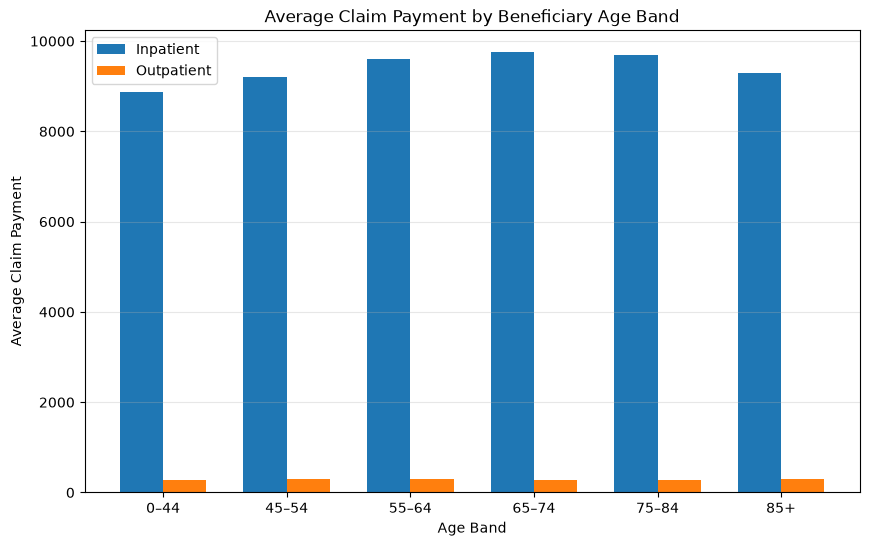

In [59]:
# --------------------------------------------------
# EDA 55: Average Claim Payment by Age Band
# --------------------------------------------------

payment_pivot = age_band_payment.pivot(
    index="Age_Band",
    columns="Claim_Type",
    values="Average_Payment"
).reset_index()

plt.figure(figsize=(10, 6))

x = np.arange(len(payment_pivot["Age_Band"]))
width = 0.35

plt.bar(
    x - width / 2,
    payment_pivot["Inpatient"],
    width,
    label="Inpatient"
)

plt.bar(
    x + width / 2,
    payment_pivot["Outpatient"],
    width,
    label="Outpatient"
)

plt.xticks(
    x,
    payment_pivot["Age_Band"].astype(str)
)

plt.title("Average Claim Payment by Beneficiary Age Band")
plt.xlabel("Age Band")
plt.ylabel("Average Claim Payment")
plt.legend()

plt.grid(
    axis="y",
    alpha=0.3
)

plt.show()

In [60]:
# --------------------------------------------------
# EDA 56: Claim Payments by ESRD Status
# --------------------------------------------------

beneficiary_esrd_lookup = beneficiary_2008[
    ["DESYNPUF_ID", "BENE_ESRD_IND"]
].copy()

# Inpatient payments by ESRD status
inpatient_esrd_payment = (
    inpatient[
        ["DESYNPUF_ID", "CLM_PMT_AMT"]
    ]
    .merge(
        beneficiary_esrd_lookup,
        on="DESYNPUF_ID",
        how="left"
    )
    .groupby("BENE_ESRD_IND", dropna=False)
    .agg(
        Claims=("CLM_PMT_AMT", "count"),
        Total_Payments=("CLM_PMT_AMT", "sum"),
        Average_Payment=("CLM_PMT_AMT", "mean"),
        Median_Payment=("CLM_PMT_AMT", "median")
    )
    .reset_index()
)

inpatient_esrd_payment["Claim_Type"] = "Inpatient"

# Outpatient payments by ESRD status
outpatient_esrd_payment = (
    outpatient[
        ["DESYNPUF_ID", "CLM_PMT_AMT"]
    ]
    .merge(
        beneficiary_esrd_lookup,
        on="DESYNPUF_ID",
        how="left"
    )
    .groupby("BENE_ESRD_IND", dropna=False)
    .agg(
        Claims=("CLM_PMT_AMT", "count"),
        Total_Payments=("CLM_PMT_AMT", "sum"),
        Average_Payment=("CLM_PMT_AMT", "mean"),
        Median_Payment=("CLM_PMT_AMT", "median")
    )
    .reset_index()
)

outpatient_esrd_payment["Claim_Type"] = "Outpatient"

esrd_payment_summary = pd.concat(
    [
        inpatient_esrd_payment,
        outpatient_esrd_payment
    ],
    ignore_index=True
)

esrd_payment_summary[
    [
        "Total_Payments",
        "Average_Payment",
        "Median_Payment"
    ]
] = (
    esrd_payment_summary[
        [
            "Total_Payments",
            "Average_Payment",
            "Median_Payment"
        ]
    ]
    .round(2)
)

display(esrd_payment_summary)

,BENE_ESRD_IND,Claims,Total_Payments,Average_Payment,Median_Payment,Claim_Type
0,0,52333,490257950.0,9368.05,7000.0,Inpatient
1,Y,14440,149002230.0,10318.71,7000.0,Inpatient
2,0,663771,153634230.0,231.46,70.0,Outpatient
3,Y,127019,70890480.0,558.11,100.0,Outpatient


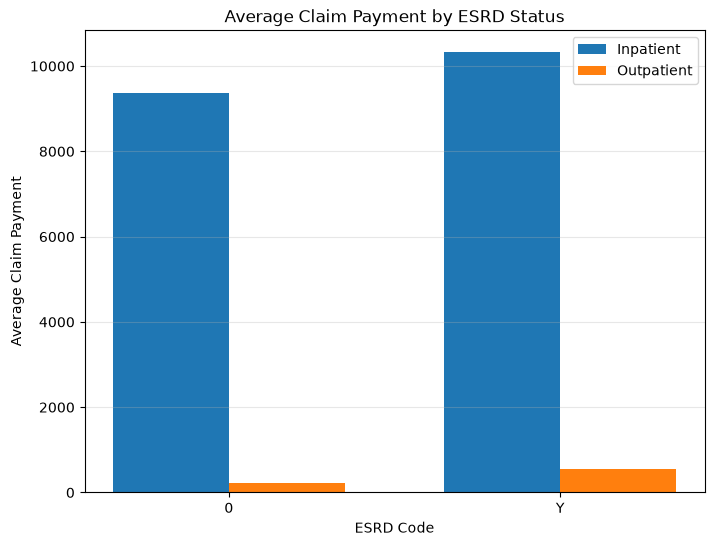

In [61]:
# --------------------------------------------------
# EDA 57: Average Claim Payment by ESRD Status
# --------------------------------------------------

esrd_payment_pivot = esrd_payment_summary.pivot(
    index="BENE_ESRD_IND",
    columns="Claim_Type",
    values="Average_Payment"
).reset_index()

plt.figure(figsize=(8, 6))

x = np.arange(len(esrd_payment_pivot["BENE_ESRD_IND"]))
width = 0.35

plt.bar(
    x - width / 2,
    esrd_payment_pivot["Inpatient"],
    width,
    label="Inpatient"
)

plt.bar(
    x + width / 2,
    esrd_payment_pivot["Outpatient"],
    width,
    label="Outpatient"
)

plt.xticks(
    x,
    esrd_payment_pivot["BENE_ESRD_IND"].astype(str)
)

plt.title("Average Claim Payment by ESRD Status")
plt.xlabel("ESRD Code")
plt.ylabel("Average Claim Payment")
plt.legend()

plt.grid(
    axis="y",
    alpha=0.3
)

plt.show()

In [62]:
# --------------------------------------------------
# EDA 58: Claims per Beneficiary by ESRD Status
# --------------------------------------------------

beneficiary_esrd_utilization = (
    beneficiary_utilization
    .reset_index()
    .merge(
        beneficiary_esrd_lookup,
        on="DESYNPUF_ID",
        how="left"
    )
)

esrd_utilization_summary = (
    beneficiary_esrd_utilization
    .groupby("BENE_ESRD_IND", dropna=False)
    .agg(
        Beneficiaries=("DESYNPUF_ID", "count"),
        Beneficiaries_with_Claims=(
            "Total_Claims",
            lambda x: (x > 0).sum()
        ),
        Total_Claims=("Total_Claims", "sum"),
        Average_Claims_per_Beneficiary=(
            "Total_Claims",
            "mean"
        ),
        Median_Claims_per_Beneficiary=(
            "Total_Claims",
            "median"
        ),
        Average_Inpatient_Claims=(
            "Inpatient_Claims",
            "mean"
        ),
        Average_Outpatient_Claims=(
            "Outpatient_Claims",
            "mean"
        )
    )
    .reset_index()
)

esrd_utilization_summary[
    [
        "Average_Claims_per_Beneficiary",
        "Median_Claims_per_Beneficiary",
        "Average_Inpatient_Claims",
        "Average_Outpatient_Claims"
    ]
] = (
    esrd_utilization_summary[
        [
            "Average_Claims_per_Beneficiary",
            "Median_Claims_per_Beneficiary",
            "Average_Inpatient_Claims",
            "Average_Outpatient_Claims"
        ]
    ]
    .round(2)
)

display(esrd_utilization_summary)

,BENE_ESRD_IND,Beneficiaries,Beneficiaries_with_Claims,Total_Claims,Average_Claims_per_Beneficiary,Median_Claims_per_Beneficiary,Average_Inpatient_Claims,Average_Outpatient_Claims
0,0,108091,78610,716104,6.63,4.0,0.48,6.14
1,Y,8261,8128,141459,17.12,15.0,1.75,15.38


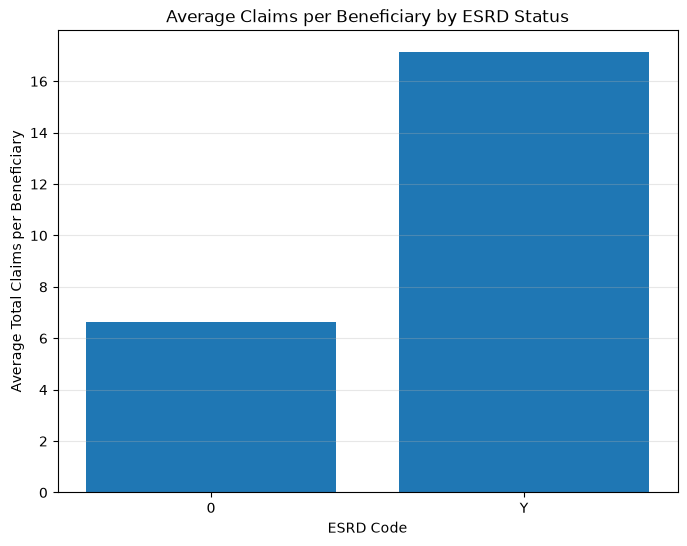

In [63]:
# --------------------------------------------------
# EDA 59: Average Claims per Beneficiary by ESRD
# --------------------------------------------------

plt.figure(figsize=(8, 6))

plt.bar(
    esrd_utilization_summary["BENE_ESRD_IND"].astype(str),
    esrd_utilization_summary["Average_Claims_per_Beneficiary"]
)

plt.title("Average Claims per Beneficiary by ESRD Status")
plt.xlabel("ESRD Code")
plt.ylabel("Average Total Claims per Beneficiary")

plt.grid(
    axis="y",
    alpha=0.3
)

plt.show()

In [64]:
# --------------------------------------------------
# EDA 60: Provider Volume Bands
# --------------------------------------------------

provider_volume_bands = (
    provider_volume_payment
    .copy()
)

provider_volume_bands["Volume_Band"] = pd.cut(
    provider_volume_bands["Claims"],
    bins=[0, 10, 25, 50, 100, 250, 500, float("inf")],
    labels=[
        "1–10",
        "11–25",
        "26–50",
        "51–100",
        "101–250",
        "251–500",
        "501+"
    ],
    right=True
)

provider_volume_band_summary = (
    provider_volume_bands
    .groupby("Volume_Band", observed=True)
    .agg(
        Providers=("PRVDR_NUM", "count"),
        Total_Claims=("Claims", "sum"),
        Total_Payments=("Total_Payments", "sum"),
        Average_Payment_per_Claim=(
            "Average_Payment",
            "mean"
        )
    )
    .reset_index()
)

provider_volume_band_summary[
    [
        "Total_Payments",
        "Average_Payment_per_Claim"
    ]
] = (
    provider_volume_band_summary[
        [
            "Total_Payments",
            "Average_Payment_per_Claim"
        ]
    ]
    .round(2)
)

display(provider_volume_band_summary)

,Volume_Band,Providers,Total_Claims,Total_Payments,Average_Payment_per_Claim
0,1–10,1386,6462,61570210.0,9551.37
1,11–25,648,10653,102325650.0,9571.81
2,26–50,329,11498,109872560.0,9532.55
3,51–100,174,12111,115032730.0,9509.40
4,101–250,116,18017,171461070.0,9551.07
5,251–500,19,6089,59955560.0,9869.79
6,501+,3,1943,19042400.0,9863.64


In [65]:
# --------------------------------------------------
# EDA 61: Highest-Volume Inpatient Providers
# --------------------------------------------------

high_volume_providers = (
    provider_volume_payment[
        provider_volume_payment["Claims"] >= 100
    ]
    .copy()
    .sort_values(
        "Claims",
        ascending=False
    )
    .reset_index(drop=True)
)

high_volume_providers["Payment_Share (%)"] = (
    high_volume_providers["Total_Payments"]
    / provider_volume_payment["Total_Payments"].sum()
    * 100
).round(2)

high_volume_providers["Claim_Share (%)"] = (
    high_volume_providers["Claims"]
    / provider_volume_payment["Claims"].sum()
    * 100
).round(2)

display(
    high_volume_providers.head(20)
)

,PRVDR_NUM,Claims,Total_Payments,Average_Payment,Payment_Share (%),Claim_Share (%)
0,23006G,772,7280500.0,9430.70,1.14,1.16
1,1000AH,634,6116900.0,9648.11,0.96,0.95
2,3600NG,537,5645000.0,10512.10,0.88,0.80
3,1401RR,431,3859280.0,8954.25,0.60,0.65
4,2600ZT,422,3919890.0,9288.84,0.61,0.63
5,2100WC,400,4046000.0,10115.00,0.63,0.60
6,3400XN,396,3841000.0,9699.49,0.60,0.59
7,0501MA,359,3718000.0,10356.55,0.58,0.54
8,4500DP,337,3315800.0,9839.17,0.52,0.50
9,1002DC,325,3255400.0,10016.62,0.51,0.49


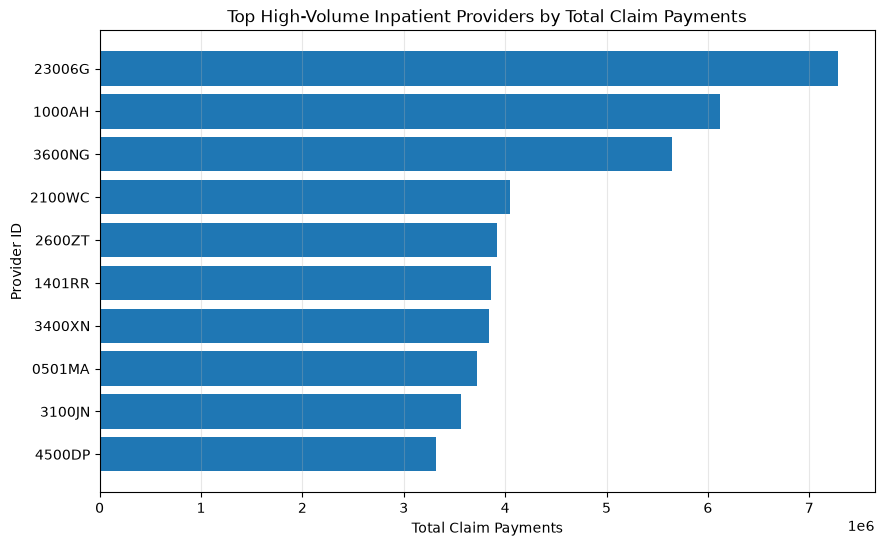

In [66]:
# --------------------------------------------------
# EDA 62: Top High-Volume Providers by Total Payments
# --------------------------------------------------

top_high_volume_payment = (
    high_volume_providers
    .sort_values(
        "Total_Payments",
        ascending=False
    )
    .head(10)
    .sort_values(
        "Total_Payments",
        ascending=True
    )
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_high_volume_payment["PRVDR_NUM"].astype(str),
    top_high_volume_payment["Total_Payments"]
)

plt.title(
    "Top High-Volume Inpatient Providers by Total Claim Payments"
)
plt.xlabel("Total Claim Payments")
plt.ylabel("Provider ID")

plt.grid(
    axis="x",
    alpha=0.3
)

plt.show()

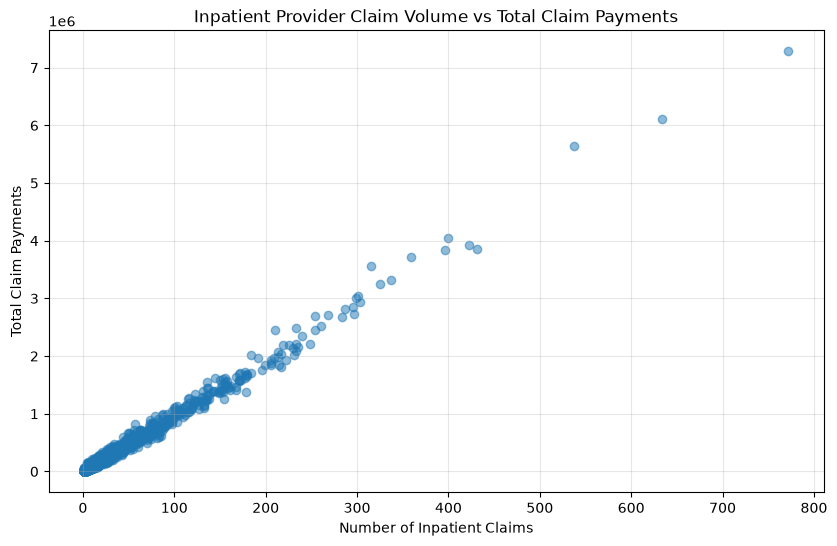

In [67]:
# --------------------------------------------------
# EDA 63: Provider Claim Volume vs Total Payments
# --------------------------------------------------

plt.figure(figsize=(10, 6))

plt.scatter(
    provider_volume_payment["Claims"],
    provider_volume_payment["Total_Payments"],
    alpha=0.5
)

plt.title("Inpatient Provider Claim Volume vs Total Claim Payments")
plt.xlabel("Number of Inpatient Claims")
plt.ylabel("Total Claim Payments")

plt.grid(
    alpha=0.3
)

plt.show()

In [68]:
# --------------------------------------------------
# EDA 64: Provider Volume-Payment Correlation
# --------------------------------------------------

provider_volume_payment_correlation = (
    provider_volume_payment[
        ["Claims", "Total_Payments"]
    ]
    .corr()
    .loc["Claims", "Total_Payments"]
)

print(
    "Pearson correlation between provider claim volume "
    "and total claim payments:"
)

print(
    round(
        provider_volume_payment_correlation,
        3
    )
)

Pearson correlation between provider claim volume and total claim payments:
0.995


In [69]:
# --------------------------------------------------
# EDA 65: Provider Average Payment vs Claim Volume
# --------------------------------------------------

provider_avg_payment_analysis = (
    provider_volume_payment[
        provider_volume_payment["Claims"] >= 50
    ]
    .copy()
)

overall_avg_payment = (
    inpatient["CLM_PMT_AMT"].mean()
)

provider_avg_payment_analysis["Payment_vs_Overall (%)"] = (
    (
        provider_avg_payment_analysis["Average_Payment"]
        / overall_avg_payment
    ) - 1
) * 100

provider_avg_payment_analysis[
    "Payment_vs_Overall (%)"
] = (
    provider_avg_payment_analysis[
        "Payment_vs_Overall (%)"
    ]
    .round(2)
)

provider_avg_payment_analysis = (
    provider_avg_payment_analysis
    .sort_values(
        "Average_Payment",
        ascending=False
    )
    .reset_index(drop=True)
)

print(
    "Overall inpatient average claim payment:",
    round(overall_avg_payment, 2)
)

print(
    "\nProviders meeting minimum 50-claim threshold:",
    len(provider_avg_payment_analysis)
)

display(
    provider_avg_payment_analysis.head(20)
)

Overall inpatient average claim payment: 9573.63

Providers meeting minimum 50-claim threshold: 319


,PRVDR_NUM,Claims,Total_Payments,Average_Payment,Payment_vs_Overall (%)
0,1500KD,57,816000.0,14315.79,49.53
1,3600VA,50,668000.0,13360.00,39.55
2,3100GR,56,727000.0,12982.14,35.60
3,10S0NQ,52,657000.0,12634.62,31.97
4,33038A,73,885600.0,12131.51,26.72
5,0600PR,79,955000.0,12088.61,26.27
6,0506TS,55,650000.0,11818.18,23.45
7,67006C,58,683000.0,11775.86,23.00
8,2801QQ,62,727000.0,11725.81,22.48
9,3302VG,210,2444600.0,11640.95,21.59


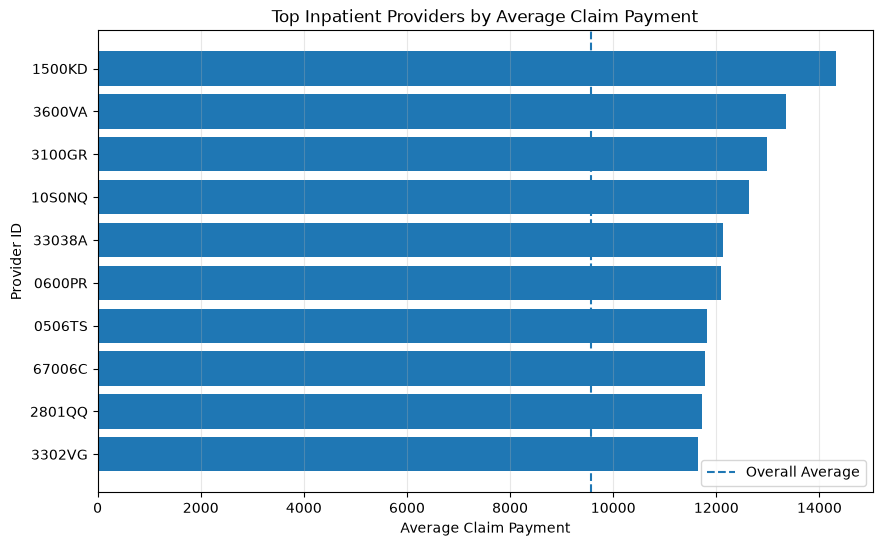

In [70]:
# --------------------------------------------------
# EDA 66: Top Providers by Average Claim Payment
# --------------------------------------------------

top_provider_avg_payment = (
    provider_avg_payment_analysis
    .head(10)
    .sort_values(
        "Average_Payment",
        ascending=True
    )
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_provider_avg_payment["PRVDR_NUM"].astype(str),
    top_provider_avg_payment["Average_Payment"]
)

plt.axvline(
    overall_avg_payment,
    linestyle="--",
    linewidth=1.5,
    label="Overall Average"
)

plt.title(
    "Top Inpatient Providers by Average Claim Payment"
)
plt.xlabel("Average Claim Payment")
plt.ylabel("Provider ID")

plt.legend()

plt.grid(
    axis="x",
    alpha=0.3
)

plt.show()

In [71]:
# --------------------------------------------------
# EDA 67: Outpatient Provider Volume and Payments
# --------------------------------------------------

outpatient_provider_volume_payment = (
    outpatient
    .groupby("PRVDR_NUM", dropna=False)
    .agg(
        Claims=("CLM_ID", "count"),
        Total_Payments=("CLM_PMT_AMT", "sum"),
        Average_Payment=("CLM_PMT_AMT", "mean")
    )
    .reset_index()
)

outpatient_provider_volume_payment = (
    outpatient_provider_volume_payment
    .sort_values(
        "Claims",
        ascending=False
    )
    .reset_index(drop=True)
)

print(
    "Number of outpatient providers:",
    len(outpatient_provider_volume_payment)
)

display(
    outpatient_provider_volume_payment.head(20)
)

Number of outpatient providers: 6294


,PRVDR_NUM,Claims,Total_Payments,Average_Payment
0,0502NA,9906,2892110.0,291.955381
1,2201DT,6084,1774980.0,291.745562
2,0505TK,5755,1741690.0,302.639444
3,2301GU,4421,1269740.0,287.206514
4,3300KJ,3951,1175830.0,297.603138
5,3400ZQ,3870,1157150.0,299.005168
6,4500NJ,3783,1117830.0,295.487708
7,1700JJ,3632,996660.0,274.410793
8,10018S,3582,1001380.0,279.558906
9,3600WB,3502,922140.0,263.318104


In [72]:
# --------------------------------------------------
# EDA 68: Top Outpatient Providers by Total Payments
# --------------------------------------------------

top_outpatient_payment_providers = (
    outpatient_provider_volume_payment
    .sort_values(
        "Total_Payments",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    top_outpatient_payment_providers.head(20)
)

,PRVDR_NUM,Claims,Total_Payments,Average_Payment
0,0502NA,9906,2892110.0,291.955381
1,2201DT,6084,1774980.0,291.745562
2,0505TK,5755,1741690.0,302.639444
3,2301GU,4421,1269740.0,287.206514
4,3300KJ,3951,1175830.0,297.603138
5,3400ZQ,3870,1157150.0,299.005168
6,4500NJ,3783,1117830.0,295.487708
7,10018S,3582,1001380.0,279.558906
8,1700JJ,3632,996660.0,274.410793
9,3600WB,3502,922140.0,263.318104


In [73]:
# --------------------------------------------------
# EDA 69: Outpatient Provider Volume-Payment Correlation
# --------------------------------------------------

outpatient_provider_correlation = (
    outpatient_provider_volume_payment[
        ["Claims", "Total_Payments"]
    ]
    .corr()
    .loc["Claims", "Total_Payments"]
)

print(
    "Pearson correlation between outpatient provider "
    "claim volume and total claim payments:"
)

print(
    round(
        outpatient_provider_correlation,
        3
    )
)

Pearson correlation between outpatient provider claim volume and total claim payments:
0.993


In [74]:
# --------------------------------------------------
# EDA 70: Outpatient Provider Average Payment
# --------------------------------------------------

outpatient_provider_avg_analysis = (
    outpatient_provider_volume_payment[
        outpatient_provider_volume_payment["Claims"] >= 50
    ]
    .copy()
)

outpatient_overall_avg_payment = (
    outpatient["CLM_PMT_AMT"].mean()
)

outpatient_provider_avg_analysis["Payment_vs_Overall (%)"] = (
    (
        outpatient_provider_avg_analysis["Average_Payment"]
        / outpatient_overall_avg_payment
    ) - 1
) * 100

outpatient_provider_avg_analysis[
    "Payment_vs_Overall (%)"
] = (
    outpatient_provider_avg_analysis[
        "Payment_vs_Overall (%)"
    ]
    .round(2)
)

outpatient_provider_avg_analysis = (
    outpatient_provider_avg_analysis
    .sort_values(
        "Average_Payment",
        ascending=False
    )
    .reset_index(drop=True)
)

print(
    "Overall outpatient average claim payment:",
    round(outpatient_overall_avg_payment, 2)
)

print(
    "\nProviders meeting minimum 50-claim threshold:",
    len(outpatient_provider_avg_analysis)
)

display(
    outpatient_provider_avg_analysis.head(20)
)

Overall outpatient average claim payment: 283.92

Providers meeting minimum 50-claim threshold: 2707


,PRVDR_NUM,Claims,Total_Payments,Average_Payment,Payment_vs_Overall (%)
0,17138K,64,49470.0,772.968750,172.24
1,1113YJ,119,88180.0,741.008403,160.99
2,2939KV,50,36320.0,726.400000,155.84
3,4913HH,73,52950.0,725.342466,155.47
4,4502DJ,164,114520.0,698.292683,145.94
5,0100JS,54,37110.0,687.222222,142.04
6,1813DJ,55,36900.0,670.909091,136.30
7,3701JR,52,34380.0,661.153846,132.86
8,2313NG,81,52410.0,647.037037,127.89
9,1413GM,125,80860.0,646.880000,127.84


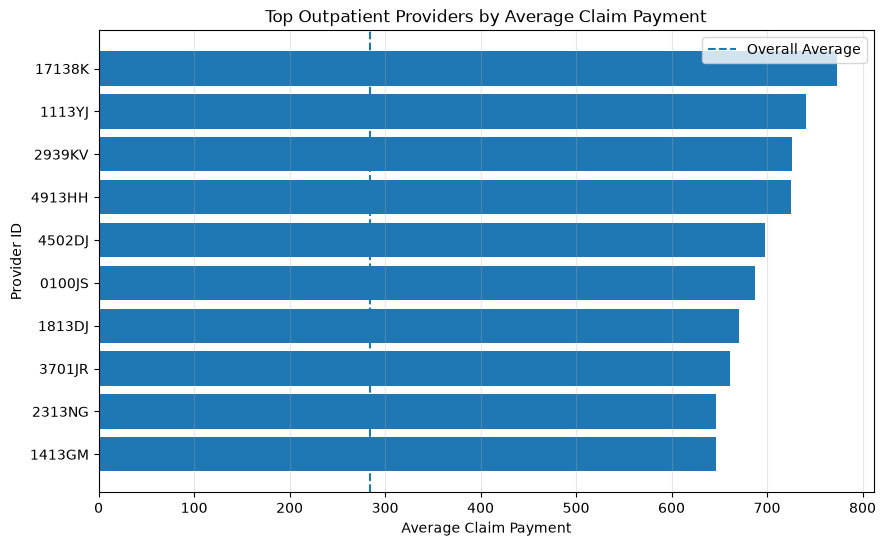

In [75]:
# --------------------------------------------------
# EDA 71: Top Outpatient Providers by Average Payment
# --------------------------------------------------

top_outpatient_avg_payment = (
    outpatient_provider_avg_analysis
    .head(10)
    .sort_values(
        "Average_Payment",
        ascending=True
    )
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_outpatient_avg_payment["PRVDR_NUM"].astype(str),
    top_outpatient_avg_payment["Average_Payment"]
)

plt.axvline(
    outpatient_overall_avg_payment,
    linestyle="--",
    linewidth=1.5,
    label="Overall Average"
)

plt.title(
    "Top Outpatient Providers by Average Claim Payment"
)
plt.xlabel("Average Claim Payment")
plt.ylabel("Provider ID")

plt.legend()

plt.grid(
    axis="x",
    alpha=0.3
)

plt.show()

In [76]:
# --------------------------------------------------
# EDA 72: Outpatient Provider Volume Bands
# --------------------------------------------------

outpatient_provider_volume_bands = (
    outpatient_provider_volume_payment
    .copy()
)

outpatient_provider_volume_bands["Volume_Band"] = pd.cut(
    outpatient_provider_volume_bands["Claims"],
    bins=[0, 10, 25, 50, 100, 250, 500, 1000, float("inf")],
    labels=[
        "1–10",
        "11–25",
        "26–50",
        "51–100",
        "101–250",
        "251–500",
        "501–1,000",
        "1,001+"
    ],
    right=True
)

outpatient_provider_volume_band_summary = (
    outpatient_provider_volume_bands
    .groupby(
        "Volume_Band",
        observed=True
    )
    .agg(
        Providers=("PRVDR_NUM", "count"),
        Total_Claims=("Claims", "sum"),
        Total_Payments=("Total_Payments", "sum"),
        Average_Payment_per_Claim=(
            "Average_Payment",
            "mean"
        )
    )
    .reset_index()
)

outpatient_provider_volume_band_summary[
    [
        "Total_Payments",
        "Average_Payment_per_Claim"
    ]
] = (
    outpatient_provider_volume_band_summary[
        [
            "Total_Payments",
            "Average_Payment_per_Claim"
        ]
    ]
    .round(2)
)

display(
    outpatient_provider_volume_band_summary
)

,Volume_Band,Providers,Total_Claims,Total_Payments,Average_Payment_per_Claim
0,1–10,1384,6634,1783510.0,264.40
1,11–25,1138,19895,5473900.0,273.97
2,26–50,1093,40343,11193560.0,277.61
3,51–100,1082,77695,21733130.0,279.30
4,101–250,915,144380,40849500.0,283.01
5,251–500,347,118559,33494340.0,282.64
6,"501–1,000",209,143814,41377210.0,287.35
7,"1,001+",126,239470,68619560.0,286.40


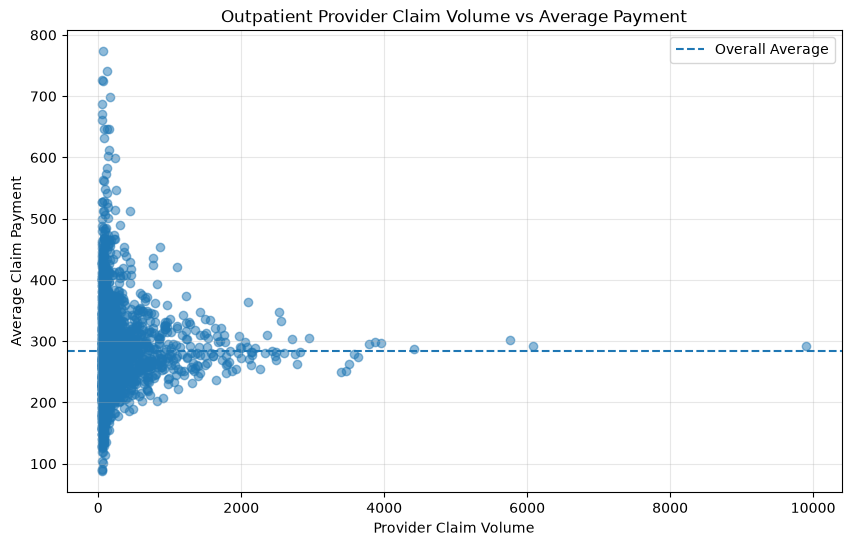

In [77]:
# --------------------------------------------------
# EDA 73: Outpatient Provider Volume vs Average Payment
# --------------------------------------------------

outpatient_provider_avg_volume = (
    outpatient_provider_volume_payment[
        outpatient_provider_volume_payment["Claims"] >= 50
    ]
    .copy()
)

plt.figure(figsize=(10, 6))

plt.scatter(
    outpatient_provider_avg_volume["Claims"],
    outpatient_provider_avg_volume["Average_Payment"],
    alpha=0.5
)

plt.axhline(
    outpatient_overall_avg_payment,
    linestyle="--",
    linewidth=1.5,
    label="Overall Average"
)

plt.title(
    "Outpatient Provider Claim Volume vs Average Payment"
)
plt.xlabel("Provider Claim Volume")
plt.ylabel("Average Claim Payment")

plt.legend()

plt.grid(
    alpha=0.3
)

plt.show()

In [78]:
# --------------------------------------------------
# EDA 74: Inpatient Provider Payment Concentration
# --------------------------------------------------

inpatient_provider_concentration = (
    provider_volume_payment
    .sort_values(
        "Total_Payments",
        ascending=False
    )
    .reset_index(drop=True)
)

total_inpatient_provider_payments = (
    inpatient_provider_concentration["Total_Payments"].sum()
)

inpatient_provider_concentration["Cumulative_Payment_Share (%)"] = (
    inpatient_provider_concentration["Total_Payments"].cumsum()
    / total_inpatient_provider_payments
    * 100
)

concentration_summary = pd.DataFrame({
    "Provider_Group": [
        "Top 1",
        "Top 5",
        "Top 10",
        "Top 25",
        "Top 50",
        "Top 100"
    ],
    "Providers": [
        1, 5, 10, 25, 50, 100
    ]
})

concentration_summary["Payment_Share (%)"] = [
    inpatient_provider_concentration.loc[n - 1, "Cumulative_Payment_Share (%)"]
    for n in concentration_summary["Providers"]
]

concentration_summary["Payment_Share (%)"] = (
    concentration_summary["Payment_Share (%)"].round(2)
)

display(concentration_summary)

print(
    "\nTotal inpatient provider payments:",
    total_inpatient_provider_payments
)

,Provider_Group,Providers,Payment_Share (%)
0,Top 1,1,1.14
1,Top 5,5,4.22
2,Top 10,10,7.09
3,Top 25,25,13.50
4,Top 50,50,21.20
5,Top 100,100,32.63



Total inpatient provider payments: 639260180.0


In [79]:
# --------------------------------------------------
# EDA 75: Outpatient Provider Payment Concentration
# --------------------------------------------------

outpatient_provider_concentration = (
    outpatient_provider_volume_payment
    .sort_values(
        "Total_Payments",
        ascending=False
    )
    .reset_index(drop=True)
)

total_outpatient_provider_payments = (
    outpatient_provider_concentration["Total_Payments"].sum()
)

outpatient_provider_concentration[
    "Cumulative_Payment_Share (%)"
] = (
    outpatient_provider_concentration["Total_Payments"].cumsum()
    / total_outpatient_provider_payments
    * 100
)

outpatient_concentration_summary = pd.DataFrame({
    "Provider_Group": [
        "Top 1",
        "Top 5",
        "Top 10",
        "Top 25",
        "Top 50",
        "Top 100"
    ],
    "Providers": [
        1, 5, 10, 25, 50, 100
    ]
})

outpatient_concentration_summary[
    "Payment_Share (%)"
] = [
    outpatient_provider_concentration.loc[
        n - 1,
        "Cumulative_Payment_Share (%)"
    ]
    for n in outpatient_concentration_summary["Providers"]
]

outpatient_concentration_summary[
    "Payment_Share (%)"
] = (
    outpatient_concentration_summary[
        "Payment_Share (%)"
    ]
    .round(2)
)

display(
    outpatient_concentration_summary
)

print(
    "\nTotal outpatient provider payments:",
    total_outpatient_provider_payments
)

,Provider_Group,Providers,Payment_Share (%)
0,Top 1,1,1.29
1,Top 5,5,3.94
2,Top 10,10,6.26
3,Top 25,25,11.49
4,Top 50,50,17.84
5,Top 100,100,27.14



Total outpatient provider payments: 224524710.0


In [80]:
# --------------------------------------------------
# EDA 76: Inpatient vs Outpatient Payment Concentration
# --------------------------------------------------

payment_concentration_comparison = (
    concentration_summary[
        ["Provider_Group", "Payment_Share (%)"]
    ]
    .rename(
        columns={
            "Payment_Share (%)": "Inpatient_Payment_Share (%)"
        }
    )
    .merge(
        outpatient_concentration_summary[
            ["Provider_Group", "Payment_Share (%)"]
        ].rename(
            columns={
                "Payment_Share (%)": "Outpatient_Payment_Share (%)"
            }
        ),
        on="Provider_Group"
    )
)

payment_concentration_comparison[
    "Difference_ percentage_points"
] = (
    payment_concentration_comparison[
        "Inpatient_Payment_Share (%)"
    ]
    - payment_concentration_comparison[
        "Outpatient_Payment_Share (%)"
    ]
).round(2)

display(
    payment_concentration_comparison
)

,Provider_Group,Inpatient_Payment_Share (%),Outpatient_Payment_Share (%),Difference_ percentage_points
0,Top 1,1.14,1.29,-0.15
1,Top 5,4.22,3.94,0.28
2,Top 10,7.09,6.26,0.83
3,Top 25,13.50,11.49,2.01
4,Top 50,21.20,17.84,3.36
5,Top 100,32.63,27.14,5.49


In [81]:
# --------------------------------------------------
# EDA 77: Highest-Payment Inpatient Claims
# --------------------------------------------------

top_inpatient_claims = (
    inpatient[
        [
            "CLM_ID",
            "DESYNPUF_ID",
            "PRVDR_NUM",
            "CLM_FROM_DT",
            "CLM_THRU_DT",
            "CLM_PMT_AMT",
            "CLM_UTLZTN_DAY_CNT"
        ]
    ]
    .sort_values(
        "CLM_PMT_AMT",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    top_inpatient_claims.head(20)
)

,CLM_ID,DESYNPUF_ID,PRVDR_NUM,CLM_FROM_DT,CLM_THRU_DT,CLM_PMT_AMT,CLM_UTLZTN_DAY_CNT
0,196991176995117,E1C6F1184ACDAE42,29T0WG,2009-02-20,2009-02-24,57000.0,4.0
1,196051177006822,2069C2B2A6FFC198,38008N,2008-03-09,2008-04-13,57000.0,40.0
2,196721176988951,90166BDEC056F2B7,0507AB,2010-07-16,2010-07-28,57000.0,12.0
3,196521176971681,1473375E6B89C4EB,2600QH,2010-09-04,2010-09-14,57000.0,10.0
4,196601177005077,1450AEA433F740EB,0900UA,2008-05-16,2008-06-09,57000.0,24.0
5,196171176982532,548881AEF38C09BD,3702VR,2008-11-13,2008-11-20,57000.0,7.0
6,196071176999623,B805EBD384FEA284,5001PC,2008-06-10,2008-06-22,57000.0,12.0
7,196031177002792,04C1FFEF655163EF,2300QQ,2009-02-01,2009-03-08,57000.0,45.0
8,196711177021745,04C1EB434801760A,3301QB,2008-01-28,2008-02-01,57000.0,4.0
9,196501176985620,FEEFBC34AF7D0C2B,3301QB,2009-06-23,2009-07-05,57000.0,12.0


In [82]:
# --------------------------------------------------
# EDA 78: Most Frequent Inpatient Payment Amounts
# --------------------------------------------------

inpatient_payment_frequency = (
    inpatient["CLM_PMT_AMT"]
    .value_counts()
    .rename_axis("CLM_PMT_AMT")
    .reset_index(name="Claim_Count")
    .sort_values(
        "Claim_Count",
        ascending=False
    )
    .reset_index(drop=True)
)

inpatient_payment_frequency["Payment_Share (%)"] = (
    inpatient_payment_frequency["Claim_Count"]
    / len(inpatient)
    * 100
).round(2)

display(
    inpatient_payment_frequency.head(20)
)

,CLM_PMT_AMT,Claim_Count,Payment_Share (%)
0,4000.0,7601,11.38
1,5000.0,7027,10.52
2,3000.0,6399,9.58
3,6000.0,5822,8.72
4,7000.0,4643,6.95
5,8000.0,4081,6.11
6,9000.0,3701,5.54
7,10000.0,3488,5.22
8,11000.0,2915,4.37
9,12000.0,2220,3.32


In [83]:
# --------------------------------------------------
# EDA 79: Most Frequent Outpatient Payment Amounts
# --------------------------------------------------

outpatient_payment_frequency = (
    outpatient["CLM_PMT_AMT"]
    .value_counts()
    .rename_axis("CLM_PMT_AMT")
    .reset_index(name="Claim_Count")
    .sort_values(
        "Claim_Count",
        ascending=False
    )
    .reset_index(drop=True)
)

outpatient_payment_frequency["Payment_Share (%)"] = (
    outpatient_payment_frequency["Claim_Count"]
    / len(outpatient)
    * 100
).round(2)

display(
    outpatient_payment_frequency.head(20)
)

,CLM_PMT_AMT,Claim_Count,Payment_Share (%)
0,100.0,78250,9.90
1,10.0,65944,8.34
2,200.0,63762,8.06
3,60.0,62244,7.87
4,30.0,52234,6.61
5,40.0,51586,6.52
6,50.0,48772,6.17
7,20.0,42166,5.33
8,80.0,38280,4.84
9,70.0,36356,4.60


In [84]:
# --------------------------------------------------
# EDA 80: Inpatient vs Outpatient Payment Distribution
# --------------------------------------------------

payment_distribution_comparison = pd.DataFrame({
    "Metric": [
        "Minimum",
        "25th Percentile",
        "Median",
        "75th Percentile",
        "90th Percentile",
        "95th Percentile",
        "99th Percentile",
        "Maximum",
        "Mean"
    ],
    "Inpatient": [
        inpatient["CLM_PMT_AMT"].min(),
        inpatient["CLM_PMT_AMT"].quantile(0.25),
        inpatient["CLM_PMT_AMT"].median(),
        inpatient["CLM_PMT_AMT"].quantile(0.75),
        inpatient["CLM_PMT_AMT"].quantile(0.90),
        inpatient["CLM_PMT_AMT"].quantile(0.95),
        inpatient["CLM_PMT_AMT"].quantile(0.99),
        inpatient["CLM_PMT_AMT"].max(),
        inpatient["CLM_PMT_AMT"].mean()
    ],
    "Outpatient": [
        outpatient["CLM_PMT_AMT"].min(),
        outpatient["CLM_PMT_AMT"].quantile(0.25),
        outpatient["CLM_PMT_AMT"].median(),
        outpatient["CLM_PMT_AMT"].quantile(0.75),
        outpatient["CLM_PMT_AMT"].quantile(0.90),
        outpatient["CLM_PMT_AMT"].quantile(0.95),
        outpatient["CLM_PMT_AMT"].quantile(0.99),
        outpatient["CLM_PMT_AMT"].max(),
        outpatient["CLM_PMT_AMT"].mean()
    ]
})

payment_distribution_comparison[
    ["Inpatient", "Outpatient"]
] = (
    payment_distribution_comparison[
        ["Inpatient", "Outpatient"]
    ]
    .round(2)
)

display(
    payment_distribution_comparison
)

,Metric,Inpatient,Outpatient
0,Minimum,-8000.00,-100.00
1,25th Percentile,4000.00,40.00
2,Median,7000.00,80.00
3,75th Percentile,11000.00,200.00
4,90th Percentile,19000.00,700.00
5,95th Percentile,29000.00,1600.00
6,99th Percentile,57000.00,3300.00
7,Maximum,57000.00,3300.00
8,Mean,9573.63,283.92


In [85]:
# --------------------------------------------------
# EDA 81: Inpatient Payment Amount Bands
# --------------------------------------------------

inpatient_payment_bands = inpatient.copy()

inpatient_payment_bands["Payment_Band"] = pd.cut(
    inpatient_payment_bands["CLM_PMT_AMT"],
    bins=[
        -float("inf"),
        0,
        5000,
        10000,
        20000,
        30000,
        40000,
        50000,
        float("inf")
    ],
    labels=[
        "Negative",
        "₹0–5K",
        "₹5K–10K",
        "₹10K–20K",
        "₹20K–30K",
        "₹30K–40K",
        "₹40K–50K",
        "₹50K+"
    ],
    right=False
)

inpatient_payment_band_summary = (
    inpatient_payment_bands
    .groupby(
        "Payment_Band",
        observed=False
    )
    .agg(
        Claims=("CLM_ID", "count"),
        Total_Payments=("CLM_PMT_AMT", "sum"),
        Average_Payment=("CLM_PMT_AMT", "mean")
    )
    .reset_index()
)

inpatient_payment_band_summary["Claim_Share (%)"] = (
    inpatient_payment_band_summary["Claims"]
    / len(inpatient)
    * 100
).round(2)

inpatient_payment_band_summary[
    ["Total_Payments", "Average_Payment"]
] = (
    inpatient_payment_band_summary[
        ["Total_Payments", "Average_Payment"]
    ]
    .round(2)
)

display(
    inpatient_payment_band_summary
)

,Payment_Band,Claims,Total_Payments,Average_Payment,Claim_Share (%)
0,Negative,55,-33540.0,-609.82,0.08
1,₹0–5K,19068,54323720.0,2848.95,28.56
2,₹5K–10K,25274,168525000.0,6667.92,37.85
3,₹10K–20K,15949,206072000.0,12920.68,23.89
4,₹20K–30K,3306,78564000.0,23764.07,4.95
5,₹30K–40K,1585,53278000.0,33613.88,2.37
6,₹40K–50K,603,26418000.0,43810.95,0.90
7,₹50K+,933,52113000.0,55855.31,1.40


In [86]:
# --------------------------------------------------
# EDA 82: Outpatient Payment Amount Bands
# --------------------------------------------------

outpatient_payment_bands = outpatient.copy()

outpatient_payment_bands["Payment_Band"] = pd.cut(
    outpatient_payment_bands["CLM_PMT_AMT"],
    bins=[
        -float("inf"),
        0,
        100,
        250,
        500,
        1000,
        2000,
        3000,
        float("inf")
    ],
    labels=[
        "Negative",
        "₹0–100",
        "₹100–250",
        "₹250–500",
        "₹500–1K",
        "₹1K–2K",
        "₹2K–3K",
        "₹3K+"
    ],
    right=False
)

outpatient_payment_band_summary = (
    outpatient_payment_bands
    .groupby(
        "Payment_Band",
        observed=False
    )
    .agg(
        Claims=("CLM_ID", "count"),
        Total_Payments=("CLM_PMT_AMT", "sum"),
        Average_Payment=("CLM_PMT_AMT", "mean")
    )
    .reset_index()
)

outpatient_payment_band_summary["Claim_Share (%)"] = (
    outpatient_payment_band_summary["Claims"]
    / len(outpatient)
    * 100
).round(2)

outpatient_payment_band_summary[
    ["Total_Payments", "Average_Payment"]
] = (
    outpatient_payment_band_summary[
        ["Total_Payments", "Average_Payment"]
    ]
    .round(2)
)

display(
    outpatient_payment_band_summary
)

,Payment_Band,Claims,Total_Payments,Average_Payment,Claim_Share (%)
0,Negative,2566,-80410.0,-31.34,0.32
1,₹0–100,460203,19840220.0,43.11,58.20
2,₹100–250,142012,20577400.0,144.90,17.96
3,₹250–500,66950,23154900.0,345.85,8.47
4,₹500–1K,56446,36064600.0,638.92,7.14
5,₹1K–2K,33474,46859500.0,1399.88,4.23
6,₹2K–3K,18476,43376100.0,2347.70,2.34
7,₹3K+,10663,34732400.0,3257.28,1.35


In [87]:
# --------------------------------------------------
# EDA 83: Claim Payment Band Distribution Comparison
# --------------------------------------------------

payment_band_comparison = pd.DataFrame({
    "Claim_Type": [
        "Inpatient",
        "Outpatient"
    ],
    "Total_Claims": [
        len(inpatient),
        len(outpatient)
    ],
    "Negative_Payment_Claims": [
        (inpatient["CLM_PMT_AMT"] < 0).sum(),
        (outpatient["CLM_PMT_AMT"] < 0).sum()
    ],
    "Zero_Payment_Claims": [
        (inpatient["CLM_PMT_AMT"] == 0).sum(),
        (outpatient["CLM_PMT_AMT"] == 0).sum()
    ],
    "Positive_Payment_Claims": [
        (inpatient["CLM_PMT_AMT"] > 0).sum(),
        (outpatient["CLM_PMT_AMT"] > 0).sum()
    ],
    "Average_Payment": [
        inpatient["CLM_PMT_AMT"].mean(),
        outpatient["CLM_PMT_AMT"].mean()
    ],
    "Median_Payment": [
        inpatient["CLM_PMT_AMT"].median(),
        outpatient["CLM_PMT_AMT"].median()
    ]
})

payment_band_comparison[
    "Negative_Share (%)"
] = (
    payment_band_comparison["Negative_Payment_Claims"]
    / payment_band_comparison["Total_Claims"]
    * 100
).round(2)

payment_band_comparison[
    "Zero_Share (%)"
] = (
    payment_band_comparison["Zero_Payment_Claims"]
    / payment_band_comparison["Total_Claims"]
    * 100
).round(2)

payment_band_comparison[
    "Positive_Share (%)"
] = (
    payment_band_comparison["Positive_Payment_Claims"]
    / payment_band_comparison["Total_Claims"]
    * 100
).round(2)

payment_band_comparison[
    ["Average_Payment", "Median_Payment"]
] = (
    payment_band_comparison[
        ["Average_Payment", "Median_Payment"]
    ]
    .round(2)
)

display(
    payment_band_comparison
)

,Claim_Type,Total_Claims,Negative_Payment_Claims,Zero_Payment_Claims,Positive_Payment_Claims,Average_Payment,Median_Payment,Negative_Share (%),Zero_Share (%),Positive_Share (%)
0,Inpatient,66773,55,2160,64558,9573.63,7000.0,0.08,3.23,96.68
1,Outpatient,790790,2566,30105,758119,283.92,80.0,0.32,3.81,95.87


In [89]:
# --------------------------------------------------
# EDA 84: Payment Status by Year
# --------------------------------------------------

inpatient_year_payment_status = (
    inpatient[
        inpatient["CLM_FROM_DT"].notna()
    ]
    .copy()
)

# Convert date column for analysis
inpatient_year_payment_status["CLM_FROM_DT"] = pd.to_datetime(
    inpatient_year_payment_status["CLM_FROM_DT"],
    errors="coerce"
)

inpatient_year_payment_status = (
    inpatient_year_payment_status[
        inpatient_year_payment_status["CLM_FROM_DT"].notna()
    ]
)

inpatient_year_payment_status["Year"] = (
    inpatient_year_payment_status["CLM_FROM_DT"]
    .dt.year
)

inpatient_year_payment_status["Payment_Status"] = np.select(
    [
        inpatient_year_payment_status["CLM_PMT_AMT"] < 0,
        inpatient_year_payment_status["CLM_PMT_AMT"] == 0,
        inpatient_year_payment_status["CLM_PMT_AMT"] > 0
    ],
    [
        "Negative",
        "Zero",
        "Positive"
    ],
    default="Unknown"
)

year_payment_status_summary = (
    inpatient_year_payment_status
    .groupby(
        ["Year", "Payment_Status"]
    )
    .agg(
        Claims=("CLM_ID", "count")
    )
    .reset_index()
)

year_totals = (
    year_payment_status_summary
    .groupby("Year")["Claims"]
    .transform("sum")
)

year_payment_status_summary["Share (%)"] = (
    year_payment_status_summary["Claims"]
    / year_totals
    * 100
).round(2)

display(
    year_payment_status_summary
)

,Year,Payment_Status,Claims,Share (%)
0,2007,Positive,216,96.43
1,2007,Zero,8,3.57
2,2008,Negative,22,0.08
3,2008,Positive,26609,96.14
4,2008,Zero,1047,3.78
5,2009,Negative,21,0.08
6,2009,Positive,24491,97.07
7,2009,Zero,719,2.85
8,2010,Negative,12,0.09
9,2010,Positive,13176,97.08


In [90]:
# --------------------------------------------------
# EDA 85: Outpatient Payment Status by Year
# --------------------------------------------------

outpatient_year_payment_status = (
    outpatient[
        outpatient["CLM_FROM_DT"].notna()
    ]
    .copy()
)

# Convert date column for analysis
outpatient_year_payment_status["CLM_FROM_DT"] = pd.to_datetime(
    outpatient_year_payment_status["CLM_FROM_DT"],
    errors="coerce"
)

outpatient_year_payment_status = (
    outpatient_year_payment_status[
        outpatient_year_payment_status["CLM_FROM_DT"].notna()
    ]
)

outpatient_year_payment_status["Year"] = (
    outpatient_year_payment_status["CLM_FROM_DT"]
    .dt.year
)

outpatient_year_payment_status["Payment_Status"] = np.select(
    [
        outpatient_year_payment_status["CLM_PMT_AMT"] < 0,
        outpatient_year_payment_status["CLM_PMT_AMT"] == 0,
        outpatient_year_payment_status["CLM_PMT_AMT"] > 0
    ],
    [
        "Negative",
        "Zero",
        "Positive"
    ],
    default="Unknown"
)

outpatient_year_payment_status_summary = (
    outpatient_year_payment_status
    .groupby(
        ["Year", "Payment_Status"]
    )
    .agg(
        Claims=("CLM_ID", "count")
    )
    .reset_index()
)

outpatient_year_totals = (
    outpatient_year_payment_status_summary
    .groupby("Year")["Claims"]
    .transform("sum")
)

outpatient_year_payment_status_summary["Share (%)"] = (
    outpatient_year_payment_status_summary["Claims"]
    / outpatient_year_totals
    * 100
).round(2)

display(
    outpatient_year_payment_status_summary
)

,Year,Payment_Status,Claims,Share (%)
0,2007,Positive,303,97.12
1,2007,Zero,9,2.88
2,2008,Negative,926,0.33
3,2008,Positive,270809,95.73
4,2008,Zero,11161,3.95
5,2009,Negative,1050,0.33
6,2009,Positive,309059,95.87
7,2009,Zero,12249,3.80
8,2010,Negative,585,0.34
9,2010,Positive,166911,95.94


In [91]:
# --------------------------------------------------
# EDA 86: Annual Claims and Payment Summary
# --------------------------------------------------

def annual_claim_payment_summary(df, claim_type):
    analysis_df = df.copy()

    analysis_df["CLM_FROM_DT"] = pd.to_datetime(
        analysis_df["CLM_FROM_DT"],
        errors="coerce"
    )

    analysis_df = analysis_df[
        analysis_df["CLM_FROM_DT"].notna()
    ].copy()

    analysis_df["Year"] = (
        analysis_df["CLM_FROM_DT"]
        .dt.year
    )

    summary = (
        analysis_df
        .groupby("Year")
        .agg(
            Claims=("CLM_ID", "count"),
            Total_Payments=("CLM_PMT_AMT", "sum"),
            Average_Payment=("CLM_PMT_AMT", "mean"),
            Median_Payment=("CLM_PMT_AMT", "median")
        )
        .reset_index()
    )

    summary["Claim_Type"] = claim_type

    return summary


inpatient_annual_summary = annual_claim_payment_summary(
    inpatient,
    "Inpatient"
)

outpatient_annual_summary = annual_claim_payment_summary(
    outpatient,
    "Outpatient"
)

annual_claim_payment_summary = pd.concat(
    [
        inpatient_annual_summary,
        outpatient_annual_summary
    ],
    ignore_index=True
)

annual_claim_payment_summary[
    [
        "Total_Payments",
        "Average_Payment",
        "Median_Payment"
    ]
] = (
    annual_claim_payment_summary[
        [
            "Total_Payments",
            "Average_Payment",
            "Median_Payment"
        ]
    ]
    .round(2)
)

annual_claim_payment_summary = (
    annual_claim_payment_summary[
        [
            "Year",
            "Claim_Type",
            "Claims",
            "Total_Payments",
            "Average_Payment",
            "Median_Payment"
        ]
    ]
    .sort_values(
        ["Year", "Claim_Type"]
    )
    .reset_index(drop=True)
)

display(
    annual_claim_payment_summary
)

,Year,Claim_Type,Claims,Total_Payments,Average_Payment,Median_Payment
0,2007,Inpatient,224,2770000.0,12366.07,8000.0
1,2007,Outpatient,312,265120.0,849.74,250.0
2,2008,Inpatient,27678,257732880.0,9311.83,7000.0
3,2008,Outpatient,282896,73141190.0,258.54,70.0
4,2009,Inpatient,25231,244810270.0,9702.76,7000.0
5,2009,Outpatient,322358,87972330.0,272.90,80.0
6,2010,Inpatient,13572,132669330.0,9775.22,7000.0
7,2010,Outpatient,173971,47913710.0,275.41,80.0


In [92]:
# --------------------------------------------------
# EDA 87: Annual Payment Share by Claim Type
# --------------------------------------------------

annual_payment_share = (
    annual_claim_payment_summary
    .copy()
)

annual_totals = (
    annual_payment_share
    .groupby("Year")["Total_Payments"]
    .transform("sum")
)

annual_payment_share["Payment_Share (%)"] = (
    annual_payment_share["Total_Payments"]
    / annual_totals
    * 100
).round(2)

display(
    annual_payment_share[
        [
            "Year",
            "Claim_Type",
            "Claims",
            "Total_Payments",
            "Payment_Share (%)"
        ]
    ]
)

,Year,Claim_Type,Claims,Total_Payments,Payment_Share (%)
0,2007,Inpatient,224,2770000.0,91.26
1,2007,Outpatient,312,265120.0,8.74
2,2008,Inpatient,27678,257732880.0,77.89
3,2008,Outpatient,282896,73141190.0,22.11
4,2009,Inpatient,25231,244810270.0,73.56
5,2009,Outpatient,322358,87972330.0,26.44
6,2010,Inpatient,13572,132669330.0,73.47
7,2010,Outpatient,173971,47913710.0,26.53


In [93]:
# --------------------------------------------------
# EDA 88: Combined Annual Claims and Payments
# --------------------------------------------------

combined_annual_summary = (
    annual_claim_payment_summary
    .groupby("Year")
    .agg(
        Total_Claims=("Claims", "sum"),
        Total_Payments=("Total_Payments", "sum")
    )
    .reset_index()
)

combined_annual_summary["Average_Payment_per_Claim"] = (
    combined_annual_summary["Total_Payments"]
    / combined_annual_summary["Total_Claims"]
).round(2)

combined_annual_summary["Payment_Growth (%)"] = (
    combined_annual_summary["Total_Payments"]
    .pct_change()
    * 100
).round(2)

combined_annual_summary["Claim_Growth (%)"] = (
    combined_annual_summary["Total_Claims"]
    .pct_change()
    * 100
).round(2)

display(
    combined_annual_summary
)

,Year,Total_Claims,Total_Payments,Average_Payment_per_Claim,Payment_Growth (%),Claim_Growth (%)
0,2007,536,3035120.0,5662.54,NaN,NaN
1,2008,310574,330874070.0,1065.36,10801.52,57842.91
2,2009,347589,332782600.0,957.40,0.58,11.92
3,2010,187543,180583040.0,962.89,-45.74,-46.04


In [94]:
# --------------------------------------------------
# EDA 89: Annual Claim Volume Share by Claim Type
# --------------------------------------------------

annual_claim_volume_share = (
    annual_claim_payment_summary
    .copy()
)

annual_claim_totals = (
    annual_claim_volume_share
    .groupby("Year")["Claims"]
    .transform("sum")
)

annual_claim_volume_share["Claim_Share (%)"] = (
    annual_claim_volume_share["Claims"]
    / annual_claim_totals
    * 100
).round(2)

display(
    annual_claim_volume_share[
        [
            "Year",
            "Claim_Type",
            "Claims",
            "Claim_Share (%)"
        ]
    ]
)

,Year,Claim_Type,Claims,Claim_Share (%)
0,2007,Inpatient,224,41.79
1,2007,Outpatient,312,58.21
2,2008,Inpatient,27678,8.91
3,2008,Outpatient,282896,91.09
4,2009,Inpatient,25231,7.26
5,2009,Outpatient,322358,92.74
6,2010,Inpatient,13572,7.24
7,2010,Outpatient,173971,92.76


In [95]:
# --------------------------------------------------
# EDA 90: Claim Volume vs Payment Contribution
# --------------------------------------------------

claim_type_contribution = pd.DataFrame({
    "Claim_Type": [
        "Inpatient",
        "Outpatient"
    ],
    "Claims": [
        len(inpatient),
        len(outpatient)
    ],
    "Total_Payments": [
        inpatient["CLM_PMT_AMT"].sum(),
        outpatient["CLM_PMT_AMT"].sum()
    ]
})

claim_type_contribution["Claim_Share (%)"] = (
    claim_type_contribution["Claims"]
    / claim_type_contribution["Claims"].sum()
    * 100
).round(2)

claim_type_contribution["Payment_Share (%)"] = (
    claim_type_contribution["Total_Payments"]
    / claim_type_contribution["Total_Payments"].sum()
    * 100
).round(2)

claim_type_contribution["Payment_per_Claim"] = (
    claim_type_contribution["Total_Payments"]
    / claim_type_contribution["Claims"]
).round(2)

claim_type_contribution["Payment_Share_minus_Claim_Share"] = (
    claim_type_contribution["Payment_Share (%)"]
    - claim_type_contribution["Claim_Share (%)"]
).round(2)

display(
    claim_type_contribution
)

,Claim_Type,Claims,Total_Payments,Claim_Share (%),Payment_Share (%),Payment_per_Claim,Payment_Share_minus_Claim_Share
0,Inpatient,66773,639260180.0,7.79,74.01,9573.63,66.22
1,Outpatient,790790,224524710.0,92.21,25.99,283.92,-66.22


In [96]:
# --------------------------------------------------
# EDA 91: Inpatient LOS vs Claim Payment Correlation
# --------------------------------------------------

los_payment_data = (
    inpatient[
        [
            "CLM_UTLZTN_DAY_CNT",
            "CLM_PMT_AMT"
        ]
    ]
    .dropna()
    .copy()
)

los_payment_correlation = (
    los_payment_data[
        [
            "CLM_UTLZTN_DAY_CNT",
            "CLM_PMT_AMT"
        ]
    ]
    .corr()
    .loc[
        "CLM_UTLZTN_DAY_CNT",
        "CLM_PMT_AMT"
    ]
)

print(
    "Pearson correlation between inpatient "
    "length of stay and claim payment:"
)

print(
    round(
        los_payment_correlation,
        3
    )
)

print(
    "\nRecords included:",
    len(los_payment_data)
)

Pearson correlation between inpatient length of stay and claim payment:
0.33

Records included: 66705


In [97]:
# --------------------------------------------------
# EDA 92: Inpatient Payment per Utilization Day
# --------------------------------------------------

inpatient_payment_intensity = (
    inpatient[
        [
            "CLM_ID",
            "CLM_UTLZTN_DAY_CNT",
            "CLM_PMT_AMT"
        ]
    ]
    .copy()
)

inpatient_payment_intensity["Payment_per_Utilization_Day"] = np.where(
    inpatient_payment_intensity["CLM_UTLZTN_DAY_CNT"] > 0,
    inpatient_payment_intensity["CLM_PMT_AMT"]
    / inpatient_payment_intensity["CLM_UTLZTN_DAY_CNT"],
    np.nan
)

payment_intensity_summary = (
    inpatient_payment_intensity[
        "Payment_per_Utilization_Day"
    ]
    .describe()
    .round(2)
)

print(
    "Payment per utilization day — positive-day claims:"
)

display(
    payment_intensity_summary
)

Payment per utilization day — positive-day claims:


count    64439.00
mean      2684.23
std       3342.98
min      -3000.00
25%       1000.00
50%       1714.29
75%       3200.00
max      57000.00
Name: Payment_per_Utilization_Day, dtype: float64

In [99]:
# --------------------------------------------------
# EDA 93: Payment Intensity by Length-of-Stay Band
# --------------------------------------------------

los_intensity_data = (
    inpatient[
        inpatient["CLM_UTLZTN_DAY_CNT"] > 0
    ]
    .copy()
)

los_intensity_data["LOS_Band"] = pd.cut(
    los_intensity_data["CLM_UTLZTN_DAY_CNT"],
    bins=[0, 3, 7, 14, 30, float("inf")],
    labels=[
        "1–3 days",
        "4–7 days",
        "8–14 days",
        "15–30 days",
        "31+ days"
    ],
    right=True
)

los_intensity_data["Payment_per_Day"] = (
    los_intensity_data["CLM_PMT_AMT"]
    / los_intensity_data["CLM_UTLZTN_DAY_CNT"]
)

los_intensity_summary = (
    los_intensity_data
    .groupby(
        "LOS_Band",
        observed=False
    )
    .agg(
        Claims=("CLM_ID", "count"),
        Total_Payments=("CLM_PMT_AMT", "sum"),
        Average_Payment=("CLM_PMT_AMT", "mean"),
        Average_LOS=("CLM_UTLZTN_DAY_CNT", "mean"),
        Average_Payment_per_Day=("Payment_per_Day", "mean")
    )
    .reset_index()
)

los_intensity_summary[
    [
        "Total_Payments",
        "Average_Payment",
        "Average_LOS",
        "Average_Payment_per_Day"
    ]
] = (
    los_intensity_summary[
        [
            "Total_Payments",
            "Average_Payment",
            "Average_LOS",
            "Average_Payment_per_Day"
        ]
    ]
    .round(2)
)

display(
    los_intensity_summary
)

,LOS_Band,Claims,Total_Payments,Average_Payment,Average_LOS,Average_Payment_per_Day
0,1–3 days,28568,203204610.0,7113.01,2.10,4060.32
1,4–7 days,21842,203549480.0,9319.18,5.16,1843.61
2,8–14 days,9739,129201800.0,13266.43,10.15,1328.82
3,15–30 days,3599,63803070.0,17728.00,19.70,927.96
4,31+ days,691,16976300.0,24567.73,43.45,614.11


In [100]:
# --------------------------------------------------
# EDA 94: Inpatient Payment Intensity Percentiles
# --------------------------------------------------

payment_intensity_percentiles = (
    inpatient_payment_intensity[
        inpatient_payment_intensity["Payment_per_Utilization_Day"]
        .notna()
    ]["Payment_per_Utilization_Day"]
    .quantile(
        [
            0.01,
            0.05,
            0.25,
            0.50,
            0.75,
            0.90,
            0.95,
            0.99
        ]
    )
    .round(2)
    .rename_axis("Percentile")
    .reset_index(name="Payment_per_Utilization_Day")
)

display(
    payment_intensity_percentiles
)

,Percentile,Payment_per_Utilization_Day
0,0.01,0.00
1,0.05,230.77
2,0.25,1000.00
3,0.50,1714.29
4,0.75,3200.00
5,0.90,5500.00
6,0.95,8000.00
7,0.99,16000.00


In [101]:
# --------------------------------------------------
# EDA 95: Highest Inpatient Payment Intensity
# --------------------------------------------------

high_intensity_claims = (
    inpatient_payment_intensity[
        inpatient_payment_intensity["CLM_UTLZTN_DAY_CNT"] >= 2
    ]
    .copy()
    .sort_values(
        "Payment_per_Utilization_Day",
        ascending=False
    )
    .reset_index(drop=True)
)

high_intensity_claims["Payment_per_Utilization_Day"] = (
    high_intensity_claims["Payment_per_Utilization_Day"]
    .round(2)
)

display(
    high_intensity_claims.head(20)
)

,CLM_ID,CLM_UTLZTN_DAY_CNT,CLM_PMT_AMT,Payment_per_Utilization_Day
0,196641176968248,2.0,57000.0,28500.0
1,196841176987247,2.0,57000.0,28500.0
2,196741176994148,2.0,57000.0,28500.0
3,196481177017860,2.0,57000.0,28500.0
4,196091177017439,2.0,57000.0,28500.0
5,196441176976166,2.0,57000.0,28500.0
6,196921177009951,2.0,57000.0,28500.0
7,196051176980164,2.0,57000.0,28500.0
8,196491176964565,2.0,57000.0,28500.0
9,196261176960425,2.0,56000.0,28000.0


In [102]:
# --------------------------------------------------
# EDA 96: Inpatient Payment Intensity Bands
# --------------------------------------------------

intensity_data = (
    inpatient_payment_intensity[
        inpatient_payment_intensity["Payment_per_Utilization_Day"]
        .notna()
    ]
    .copy()
)

intensity_data["Intensity_Band"] = pd.cut(
    intensity_data["Payment_per_Utilization_Day"],
    bins=[
        -float("inf"),
        0,
        1000,
        2000,
        5000,
        10000,
        float("inf")
    ],
    labels=[
        "≤ ₹0",
        "₹1–1K",
        "₹1K–2K",
        "₹2K–5K",
        "₹5K–10K",
        "> ₹10K"
    ],
    right=True
)

intensity_summary = (
    intensity_data
    .groupby(
        "Intensity_Band",
        observed=False
    )
    .agg(
        Claims=("CLM_ID", "count"),
        Total_Payments=("CLM_PMT_AMT", "sum"),
        Average_Payment_per_Day=(
            "Payment_per_Utilization_Day",
            "mean"
        )
    )
    .reset_index()
)

intensity_summary["Claim_Share (%)"] = (
    intensity_summary["Claims"]
    / intensity_summary["Claims"].sum()
    * 100
).round(2)

intensity_summary[
    [
        "Total_Payments",
        "Average_Payment_per_Day"
    ]
] = (
    intensity_summary[
        [
            "Total_Payments",
            "Average_Payment_per_Day"
        ]
    ]
    .round(2)
)

display(
    intensity_summary
)

,Intensity_Band,Claims,Total_Payments,Average_Payment_per_Day,Claim_Share (%)
0,≤ ₹0,2135,-33540.0,-5.37,3.31
1,₹1–1K,17457,98431800.0,693.32,27.09
2,₹1K–2K,18859,160631000.0,1580.88,29.27
3,₹2K–5K,18861,227810000.0,3334.03,29.27
4,₹5K–10K,5280,88803000.0,7100.08,8.19
5,> ₹10K,1847,41093000.0,16617.04,2.87


In [103]:
# --------------------------------------------------
# EDA 97: Provider Payment Intensity
# --------------------------------------------------

provider_intensity_data = (
    inpatient[
        inpatient["CLM_UTLZTN_DAY_CNT"] > 0
    ]
    [
        [
            "PRVDR_NUM",
            "CLM_ID",
            "CLM_UTLZTN_DAY_CNT",
            "CLM_PMT_AMT"
        ]
    ]
    .copy()
)

provider_intensity_data["Payment_per_Day"] = (
    provider_intensity_data["CLM_PMT_AMT"]
    / provider_intensity_data["CLM_UTLZTN_DAY_CNT"]
)

provider_intensity_summary = (
    provider_intensity_data
    .groupby("PRVDR_NUM")
    .agg(
        Claims=("CLM_ID", "count"),
        Total_Payments=("CLM_PMT_AMT", "sum"),
        Total_Utilization_Days=(
            "CLM_UTLZTN_DAY_CNT",
            "sum"
        ),
        Average_Payment_per_Day=(
            "Payment_per_Day",
            "mean"
        )
    )
    .reset_index()
)

provider_intensity_summary = (
    provider_intensity_summary[
        provider_intensity_summary["Claims"] >= 50
    ]
    .sort_values(
        "Average_Payment_per_Day",
        ascending=False
    )
    .reset_index(drop=True)
)

provider_intensity_summary[
    [
        "Total_Payments",
        "Total_Utilization_Days",
        "Average_Payment_per_Day"
    ]
] = (
    provider_intensity_summary[
        [
            "Total_Payments",
            "Total_Utilization_Days",
            "Average_Payment_per_Day"
        ]
    ]
    .round(2)
)

display(
    provider_intensity_summary.head(20)
)

,PRVDR_NUM,Claims,Total_Payments,Total_Utilization_Days,Average_Payment_per_Day
0,10S0NQ,50,638000.0,359.0,4229.10
1,0504BP,73,759000.0,342.0,3937.82
2,27006D,58,498400.0,224.0,3882.74
3,3303YT,90,1015500.0,500.0,3687.71
4,4500YG,100,1073400.0,489.0,3683.60
5,1001WM,123,1344040.0,616.0,3597.02
6,1000YM,54,589000.0,311.0,3570.54
7,1002QH,57,543000.0,291.0,3555.24
8,5200GV,70,701000.0,378.0,3511.01
9,0506GC,85,757300.0,398.0,3490.82


In [104]:
# --------------------------------------------------
# EDA 98: Provider Payment Intensity vs Benchmark
# --------------------------------------------------

overall_intensity = (
    inpatient_payment_intensity[
        inpatient_payment_intensity[
            "Payment_per_Utilization_Day"
        ].notna()
    ]["Payment_per_Utilization_Day"]
    .mean()
)

provider_intensity_benchmark = (
    provider_intensity_summary
    .copy()
)

provider_intensity_benchmark["Overall_Benchmark"] = (
    overall_intensity
)

provider_intensity_benchmark["Above_Benchmark (%)"] = (
    (
        provider_intensity_benchmark["Average_Payment_per_Day"]
        / overall_intensity
    ) - 1
) * 100

provider_intensity_benchmark[
    "Above_Benchmark (%)"
] = (
    provider_intensity_benchmark[
        "Above_Benchmark (%)"
    ]
    .round(2)
)

print(
    f"Overall inpatient payment-per-utilization-day benchmark: "
    f"₹{overall_intensity:,.2f}"
)

display(
    provider_intensity_benchmark.head(20)
)

Overall inpatient payment-per-utilization-day benchmark: ₹2,684.23


,PRVDR_NUM,Claims,Total_Payments,Total_Utilization_Days,Average_Payment_per_Day,Overall_Benchmark,Above_Benchmark (%)
0,10S0NQ,50,638000.0,359.0,4229.10,2684.227309,57.55
1,0504BP,73,759000.0,342.0,3937.82,2684.227309,46.70
2,27006D,58,498400.0,224.0,3882.74,2684.227309,44.65
3,3303YT,90,1015500.0,500.0,3687.71,2684.227309,37.38
4,4500YG,100,1073400.0,489.0,3683.60,2684.227309,37.23
5,1001WM,123,1344040.0,616.0,3597.02,2684.227309,34.01
6,1000YM,54,589000.0,311.0,3570.54,2684.227309,33.02
7,1002QH,57,543000.0,291.0,3555.24,2684.227309,32.45
8,5200GV,70,701000.0,378.0,3511.01,2684.227309,30.80
9,0506GC,85,757300.0,398.0,3490.82,2684.227309,30.05


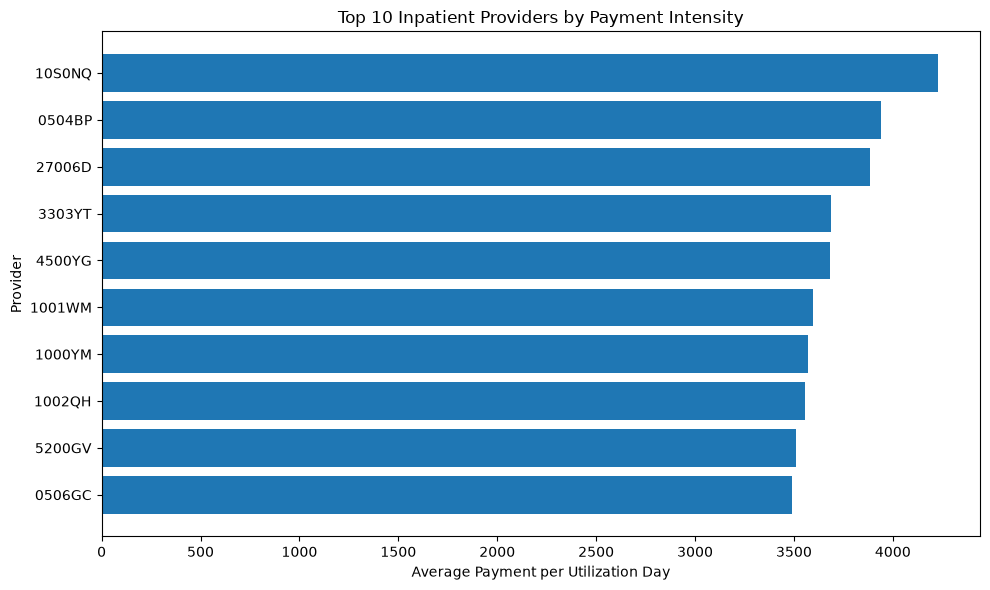

In [105]:
# --------------------------------------------------
# EDA 99: Top Providers by Payment Intensity
# --------------------------------------------------

top_provider_intensity = (
    provider_intensity_benchmark
    .head(10)
    .sort_values(
        "Average_Payment_per_Day",
        ascending=True
    )
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_provider_intensity["PRVDR_NUM"],
    top_provider_intensity["Average_Payment_per_Day"]
)

plt.xlabel("Average Payment per Utilization Day")
plt.ylabel("Provider")
plt.title(
    "Top 10 Inpatient Providers by Payment Intensity"
)

plt.tight_layout()
plt.show()

In [106]:
# --------------------------------------------------
# EDA 100: Provider Utilization vs Payment Intensity
# --------------------------------------------------

provider_intensity_relationship = (
    provider_intensity_data
    .groupby("PRVDR_NUM")
    .agg(
        Claims=("CLM_ID", "count"),
        Average_Utilization_Days=(
            "CLM_UTLZTN_DAY_CNT",
            "mean"
        ),
        Average_Payment_per_Day=(
            "Payment_per_Day",
            "mean"
        ),
        Total_Payments=("CLM_PMT_AMT", "sum")
    )
    .reset_index()
)

provider_intensity_relationship = (
    provider_intensity_relationship[
        provider_intensity_relationship["Claims"] >= 50
    ]
    .copy()
)

provider_intensity_correlation = (
    provider_intensity_relationship[
        [
            "Average_Utilization_Days",
            "Average_Payment_per_Day"
        ]
    ]
    .corr()
    .iloc[0, 1]
)

print(
    "Pearson correlation between provider average "
    "utilization days and average payment per day:"
)
print(
    round(provider_intensity_correlation, 3)
)

display(
    provider_intensity_relationship
    .sort_values(
        "Average_Utilization_Days",
        ascending=False
    )
    .head(20)
)

Pearson correlation between provider average utilization days and average payment per day:
-0.29


,PRVDR_NUM,Claims,Average_Utilization_Days,Average_Payment_per_Day,Total_Payments
1821,3600VA,50,8.380000,3365.687620,668000.0
1166,2200PP,60,7.616667,2468.172649,649000.0
2136,44006N,51,7.607843,2161.040657,461000.0
2085,4200CT,58,7.586207,2009.649202,530000.0
304,0504ZK,52,7.500000,2401.259596,563000.0
583,1002SK,57,7.403509,2234.695441,589000.0
1988,3900UC,73,7.369863,2728.929238,659000.0
1375,2601ST,54,7.351852,2240.140337,610000.0
660,1101AT,55,7.290909,2829.978248,583100.0
1263,2400KN,65,7.261538,2732.497543,708000.0


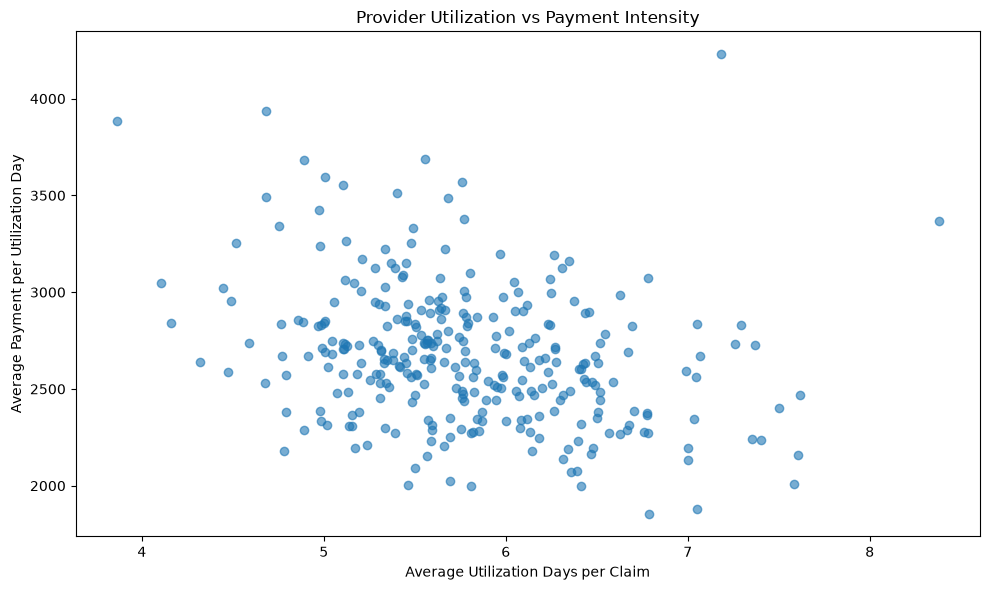

In [107]:
# --------------------------------------------------
# EDA 101: Provider Utilization vs Payment Intensity
# --------------------------------------------------

plt.figure(figsize=(10, 6))

plt.scatter(
    provider_intensity_relationship["Average_Utilization_Days"],
    provider_intensity_relationship["Average_Payment_per_Day"],
    alpha=0.6
)

plt.xlabel("Average Utilization Days per Claim")
plt.ylabel("Average Payment per Utilization Day")
plt.title(
    "Provider Utilization vs Payment Intensity"
)

plt.tight_layout()
plt.show()

In [108]:
# --------------------------------------------------
# EDA 102: Provider Payment Intensity Bands
# --------------------------------------------------

provider_intensity_bands = (
    provider_intensity_relationship
    .copy()
)

provider_intensity_bands["Intensity_Band"] = pd.cut(
    provider_intensity_bands["Average_Payment_per_Day"],
    bins=[
        -float("inf"),
        1000,
        2000,
        3000,
        4000,
        float("inf")
    ],
    labels=[
        "≤ ₹1K/day",
        "₹1K–2K/day",
        "₹2K–3K/day",
        "₹3K–4K/day",
        "> ₹4K/day"
    ],
    right=True
)

provider_intensity_band_summary = (
    provider_intensity_bands
    .groupby(
        "Intensity_Band",
        observed=False
    )
    .agg(
        Providers=("PRVDR_NUM", "count"),
        Total_Claims=("Claims", "sum"),
        Total_Payments=("Total_Payments", "sum"),
        Average_Payment_per_Day=(
            "Average_Payment_per_Day",
            "mean"
        )
    )
    .reset_index()
)

provider_intensity_band_summary[
    [
        "Total_Payments",
        "Average_Payment_per_Day"
    ]
] = (
    provider_intensity_band_summary[
        [
            "Total_Payments",
            "Average_Payment_per_Day"
        ]
    ]
    .round(2)
)

provider_intensity_band_summary["Provider_Share (%)"] = (
    provider_intensity_band_summary["Providers"]
    / provider_intensity_band_summary["Providers"].sum()
    * 100
).round(2)

display(
    provider_intensity_band_summary
)

,Intensity_Band,Providers,Total_Claims,Total_Payments,Average_Payment_per_Day,Provider_Share (%)
0,≤ ₹1K/day,0,0,0.0,NaN,0.00
1,₹1K–2K/day,4,317,2553000.0,1932.85,1.29
2,₹2K–3K/day,260,32241,306083340.0,2581.61,84.14
3,₹3K–4K/day,44,4116,42638130.0,3269.19,14.24
4,> ₹4K/day,1,50,638000.0,4229.10,0.32


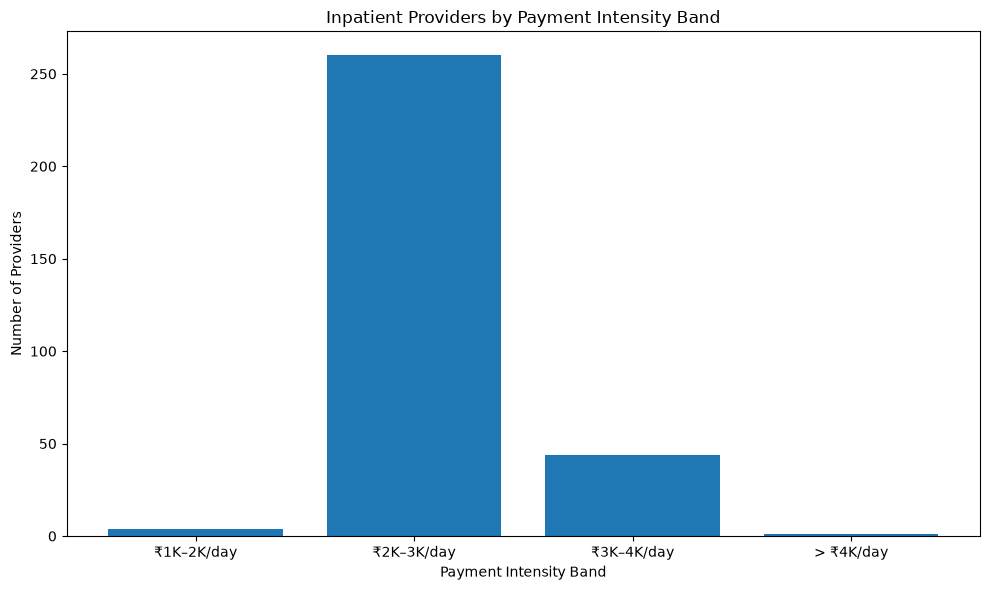

In [109]:
# --------------------------------------------------
# EDA 103: Provider Payment Intensity Band Visualization
# --------------------------------------------------

provider_intensity_chart_data = (
    provider_intensity_band_summary[
        provider_intensity_band_summary["Providers"] > 0
    ]
    .copy()
)

plt.figure(figsize=(10, 6))

plt.bar(
    provider_intensity_chart_data["Intensity_Band"].astype(str),
    provider_intensity_chart_data["Providers"]
)

plt.xlabel("Payment Intensity Band")
plt.ylabel("Number of Providers")
plt.title(
    "Inpatient Providers by Payment Intensity Band"
)

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [111]:
# --------------------------------------------------
# EDA 104: Beneficiary Claim Payment Summary
# --------------------------------------------------

inpatient_beneficiary_payments = (
    inpatient
    .groupby("DESYNPUF_ID")
    .agg(
        Inpatient_Claims=("CLM_ID", "count"),
        Inpatient_Payments=("CLM_PMT_AMT", "sum")
    )
    .reset_index()
)

outpatient_beneficiary_payments = (
    outpatient
    .groupby("DESYNPUF_ID")
    .agg(
        Outpatient_Claims=("CLM_ID", "count"),
        Outpatient_Payments=("CLM_PMT_AMT", "sum")
    )
    .reset_index()
)

beneficiary_payment_summary = (
    inpatient_beneficiary_payments
    .merge(
        outpatient_beneficiary_payments,
        on="DESYNPUF_ID",
        how="outer"
    )
    .fillna(0)
)

beneficiary_payment_summary["Total_Claims"] = (
    beneficiary_payment_summary["Inpatient_Claims"]
    + beneficiary_payment_summary["Outpatient_Claims"]
)

beneficiary_payment_summary["Total_Payments"] = (
    beneficiary_payment_summary["Inpatient_Payments"]
    + beneficiary_payment_summary["Outpatient_Payments"]
)

beneficiary_payment_summary["Average_Payment_per_Claim"] = (
    beneficiary_payment_summary["Total_Payments"]
    / beneficiary_payment_summary["Total_Claims"]
)

beneficiary_payment_summary[
    [
        "Inpatient_Payments",
        "Outpatient_Payments",
        "Total_Payments",
        "Average_Payment_per_Claim"
    ]
] = (
    beneficiary_payment_summary[
        [
            "Inpatient_Payments",
            "Outpatient_Payments",
            "Total_Payments",
            "Average_Payment_per_Claim"
        ]
    ]
    .round(2)
)

display(
    beneficiary_payment_summary
    .sort_values(
        "Total_Payments",
        ascending=False
    )
    .head(20)
)

,DESYNPUF_ID,Inpatient_Claims,Inpatient_Payments,Outpatient_Claims,Outpatient_Payments,Total_Claims,Total_Payments,Average_Payment_per_Claim
76839,E2D39E24FCF427D5,9.0,185000.0,43.0,59180.0,52.0,244180.0,4695.77
69706,CD57573A5B77AAFE,14.0,204000.0,46.0,39890.0,60.0,243890.0,4064.83
59276,AEF310232161AC91,9.0,174000.0,39.0,42480.0,48.0,216480.0,4510.00
20067,3A9D94388C426924,12.0,209000.0,22.0,5020.0,34.0,214020.0,6294.71
84333,F8F72B475A3381DC,8.0,163000.0,46.0,49890.0,54.0,212890.0,3942.41
6117,11B3642EFC2521EB,8.0,165000.0,34.0,45420.0,42.0,210420.0,5010.00
42974,7E00D9D78DAA008D,9.0,189000.0,21.0,10280.0,30.0,199280.0,6642.67
48869,8FBF91DCA969CB07,5.0,153000.0,42.0,45880.0,47.0,198880.0,4231.49
85362,FC02104A9F15D57C,13.0,190000.0,24.0,4930.0,37.0,194930.0,5268.38
46682,893882C572AC525E,6.0,145000.0,42.0,48850.0,48.0,193850.0,4038.54


In [112]:
# --------------------------------------------------
# EDA 105: Beneficiary Payment Distribution
# --------------------------------------------------

beneficiary_payment_percentiles = (
    beneficiary_payment_summary["Total_Payments"]
    .quantile(
        [
            0.50,
            0.75,
            0.90,
            0.95,
            0.99
        ]
    )
    .round(2)
    .rename_axis("Percentile")
    .reset_index(name="Total_Payments")
)

display(
    beneficiary_payment_percentiles
)

,Percentile,Total_Payments
0,0.50,3480.0
1,0.75,11790.0
2,0.90,26550.0
3,0.95,42331.5
4,0.99,85154.1


In [113]:
# --------------------------------------------------
# EDA 106: High-Payment Beneficiary Group
# --------------------------------------------------

high_payment_threshold = (
    beneficiary_payment_summary["Total_Payments"]
    .quantile(0.95)
)

beneficiary_payment_summary["Payment_Group"] = np.where(
    beneficiary_payment_summary["Total_Payments"]
    >= high_payment_threshold,
    "High Payment",
    "Standard Payment"
)

payment_group_summary = (
    beneficiary_payment_summary
    .groupby("Payment_Group")
    .agg(
        Beneficiaries=("DESYNPUF_ID", "count"),
        Total_Claims=("Total_Claims", "sum"),
        Total_Payments=("Total_Payments", "sum"),
        Average_Payment=("Total_Payments", "mean"),
        Median_Payment=("Total_Payments", "median")
    )
    .reset_index()
)

payment_group_summary["Beneficiary_Share (%)"] = (
    payment_group_summary["Beneficiaries"]
    / payment_group_summary["Beneficiaries"].sum()
    * 100
).round(2)

payment_group_summary["Payment_Share (%)"] = (
    payment_group_summary["Total_Payments"]
    / payment_group_summary["Total_Payments"].sum()
    * 100
).round(2)

payment_group_summary[
    [
        "Total_Payments",
        "Average_Payment",
        "Median_Payment"
    ]
] = (
    payment_group_summary[
        [
            "Total_Payments",
            "Average_Payment",
            "Median_Payment"
        ]
    ]
    .round(2)
)

print(
    f"95th percentile high-payment threshold: "
    f"₹{high_payment_threshold:,.2f}"
)

display(
    payment_group_summary
)

95th percentile high-payment threshold: ₹42,331.50


,Payment_Group,Beneficiaries,Total_Claims,Total_Payments,Average_Payment,Median_Payment,Beneficiary_Share (%),Payment_Share (%)
0,High Payment,4337,99157.0,298211130.0,68759.77,60360.0,5.0,34.52
1,Standard Payment,82401,758406.0,565573760.0,6863.68,3030.0,95.0,65.48


In [114]:
# --------------------------------------------------
# EDA 107: Payment Group Utilization Comparison
# --------------------------------------------------

payment_group_utilization = (
    beneficiary_payment_summary
    .groupby("Payment_Group")
    .agg(
        Beneficiaries=("DESYNPUF_ID", "count"),
        Total_Claims=("Total_Claims", "sum"),
        Average_Claims_per_Beneficiary=(
            "Total_Claims",
            "mean"
        ),
        Median_Claims_per_Beneficiary=(
            "Total_Claims",
            "median"
        ),
        Average_Total_Payment=(
            "Total_Payments",
            "mean"
        ),
        Median_Total_Payment=(
            "Total_Payments",
            "median"
        )
    )
    .reset_index()
)

payment_group_utilization[
    [
        "Average_Claims_per_Beneficiary",
        "Median_Claims_per_Beneficiary",
        "Average_Total_Payment",
        "Median_Total_Payment"
    ]
] = (
    payment_group_utilization[
        [
            "Average_Claims_per_Beneficiary",
            "Median_Claims_per_Beneficiary",
            "Average_Total_Payment",
            "Median_Total_Payment"
        ]
    ]
    .round(2)
)

display(
    payment_group_utilization
)

,Payment_Group,Beneficiaries,Total_Claims,Average_Claims_per_Beneficiary,Median_Claims_per_Beneficiary,Average_Total_Payment,Median_Total_Payment
0,High Payment,4337,99157.0,22.86,21.0,68759.77,60360.0
1,Standard Payment,82401,758406.0,9.20,7.0,6863.68,3030.0


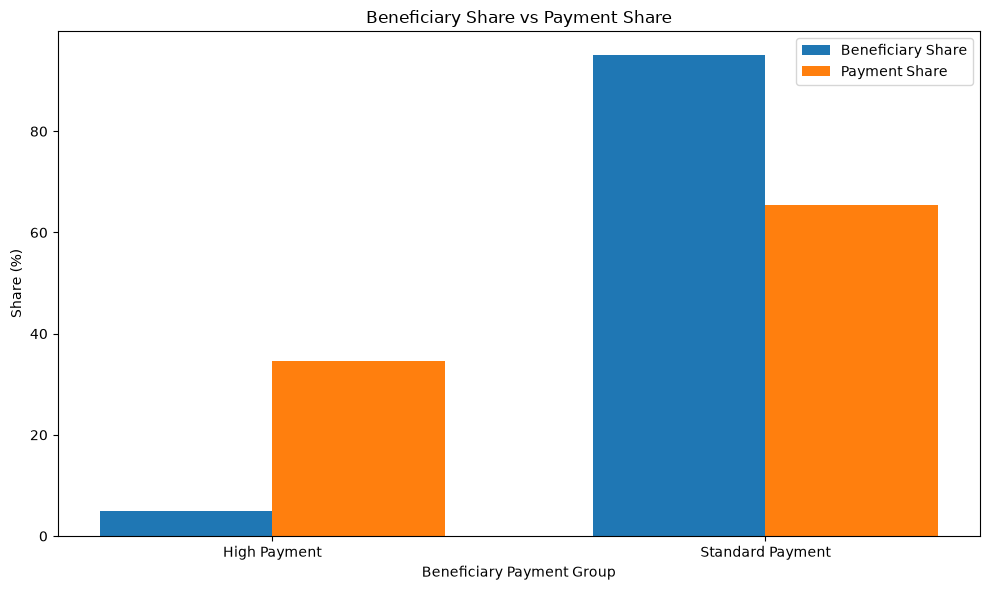

In [115]:
# --------------------------------------------------
# EDA 108: Beneficiary Payment Concentration
# --------------------------------------------------

payment_concentration_chart = (
    payment_group_summary[
        [
            "Payment_Group",
            "Beneficiary_Share (%)",
            "Payment_Share (%)"
        ]
    ]
    .copy()
)

payment_concentration_chart = (
    payment_concentration_chart
    .sort_values(
        "Beneficiary_Share (%)"
    )
)

plt.figure(figsize=(10, 6))

x = np.arange(
    len(payment_concentration_chart)
)

width = 0.35

plt.bar(
    x - width / 2,
    payment_concentration_chart["Beneficiary_Share (%)"],
    width,
    label="Beneficiary Share"
)

plt.bar(
    x + width / 2,
    payment_concentration_chart["Payment_Share (%)"],
    width,
    label="Payment Share"
)

plt.xlabel("Beneficiary Payment Group")
plt.ylabel("Share (%)")
plt.title(
    "Beneficiary Share vs Payment Share"
)

plt.xticks(
    x,
    payment_concentration_chart["Payment_Group"]
)

plt.legend()

plt.tight_layout()
plt.show()

In [118]:
# --------------------------------------------------
# EDA 109: High-Payment Beneficiary Service Mix
# --------------------------------------------------

high_payment_beneficiaries = beneficiary_payment_summary[
    beneficiary_payment_summary["Payment_Group"] == "High Payment"
].copy()

high_payment_service_mix = pd.DataFrame({
    "Metric": [
        "High-Payment Beneficiaries",
        "Inpatient Claims",
        "Outpatient Claims",
        "Inpatient Payments",
        "Outpatient Payments",
        "Total Payments"
    ],
    "Value": [
        high_payment_beneficiaries["DESYNPUF_ID"].nunique(),
        high_payment_beneficiaries["Inpatient_Claims"].sum(),
        high_payment_beneficiaries["Outpatient_Claims"].sum(),
        high_payment_beneficiaries["Inpatient_Payments"].sum(),
        high_payment_beneficiaries["Outpatient_Payments"].sum(),
        high_payment_beneficiaries["Total_Payments"].sum()
    ]
})

inpatient_claims = high_payment_beneficiaries[
    "Inpatient_Claims"
].sum()

outpatient_claims = high_payment_beneficiaries[
    "Outpatient_Claims"
].sum()

inpatient_payments = high_payment_beneficiaries[
    "Inpatient_Payments"
].sum()

total_payments = high_payment_beneficiaries[
    "Total_Payments"
].sum()

print(
    f"Inpatient claim share: "
    f"{inpatient_claims / (inpatient_claims + outpatient_claims) * 100:.2f}%"
)

print(
    f"Outpatient claim share: "
    f"{outpatient_claims / (inpatient_claims + outpatient_claims) * 100:.2f}%"
)

print(
    f"Inpatient payment share: "
    f"{inpatient_payments / total_payments * 100:.2f}%"
)

print(
    f"Outpatient payment share: "
    f"{100 - (inpatient_payments / total_payments * 100):.2f}%"
)

display(
    high_payment_service_mix
)

Inpatient claim share: 15.83%
Outpatient claim share: 84.17%
Inpatient payment share: 80.34%
Outpatient payment share: 19.66%


,Metric,Value
0,High-Payment Beneficiaries,4337.0
1,Inpatient Claims,15700.0
2,Outpatient Claims,83457.0
3,Inpatient Payments,239573970.0
4,Outpatient Payments,58637160.0
5,Total Payments,298211130.0


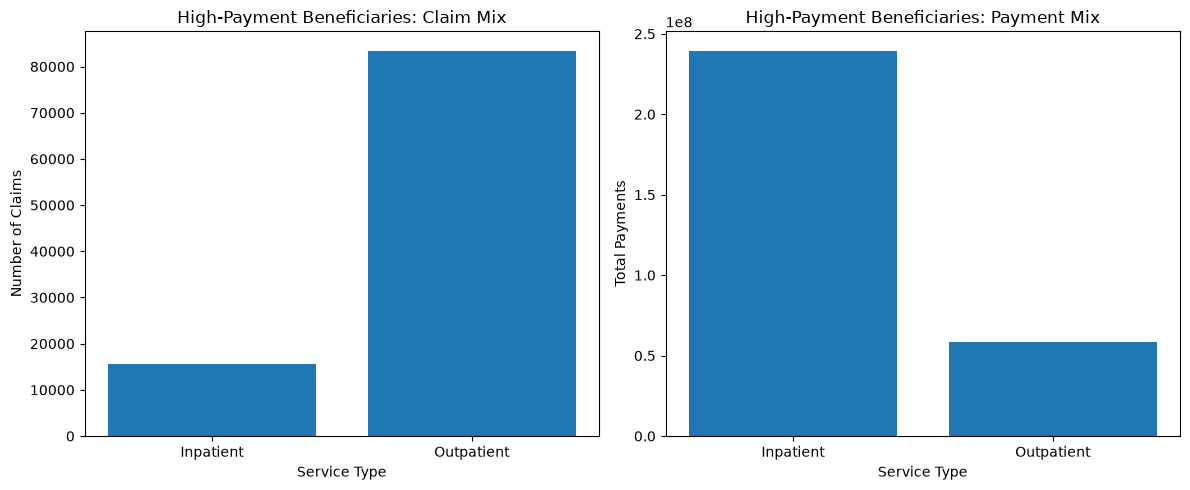

In [119]:
# --------------------------------------------------
# EDA 110: High-Payment Beneficiary Service Mix
# --------------------------------------------------

service_mix_chart = pd.DataFrame({
    "Service_Type": [
        "Inpatient",
        "Outpatient"
    ],
    "Claims": [
        inpatient_claims,
        outpatient_claims
    ],
    "Payments": [
        inpatient_payments,
        high_payment_beneficiaries["Outpatient_Payments"].sum()
    ]
})

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 5)
)

axes[0].bar(
    service_mix_chart["Service_Type"],
    service_mix_chart["Claims"]
)

axes[0].set_xlabel("Service Type")
axes[0].set_ylabel("Number of Claims")
axes[0].set_title(
    "High-Payment Beneficiaries: Claim Mix"
)

axes[1].bar(
    service_mix_chart["Service_Type"],
    service_mix_chart["Payments"]
)

axes[1].set_xlabel("Service Type")
axes[1].set_ylabel("Total Payments")
axes[1].set_title(
    "High-Payment Beneficiaries: Payment Mix"
)

plt.tight_layout()
plt.show()

In [121]:
# --------------------------------------------------
# EDA 111: Executive Summary of Key Findings
# --------------------------------------------------

total_claims = len(inpatient) + len(outpatient)

inpatient_payments_total = inpatient["CLM_PMT_AMT"].sum()
outpatient_payments_total = outpatient["CLM_PMT_AMT"].sum()

total_payments = (
    inpatient_payments_total
    + outpatient_payments_total
)

inpatient_claim_share = (
    len(inpatient) / total_claims * 100
)

outpatient_claim_share = (
    len(outpatient) / total_claims * 100
)

inpatient_payment_share = (
    inpatient_payments_total
    / total_payments
    * 100
)

outpatient_payment_share = (
    outpatient_payments_total
    / total_payments
    * 100
)

high_payment_beneficiary_count = (
    high_payment_beneficiaries["DESYNPUF_ID"].nunique()
)

total_beneficiary_count = (
    beneficiary_payment_summary["DESYNPUF_ID"].nunique()
)

high_payment_beneficiary_share = (
    high_payment_beneficiary_count
    / total_beneficiary_count
    * 100
)

high_payment_total = (
    high_payment_beneficiaries["Total_Payments"].sum()
)

high_payment_share = (
    high_payment_total
    / total_payments
    * 100
)

high_payment_inpatient_claim_share = (
    inpatient_claims
    / (inpatient_claims + outpatient_claims)
    * 100
)

high_payment_outpatient_claim_share = (
    outpatient_claims
    / (inpatient_claims + outpatient_claims)
    * 100
)

high_payment_inpatient_payment_share = (
    inpatient_payments
    / high_payment_total
    * 100
)

high_payment_outpatient_payment_share = (
    high_payment_beneficiaries["Outpatient_Payments"].sum()
    / high_payment_total
    * 100
)

print("==============================================")
print("HEALTHCARE CLAIMS & REVENUE ANALYTICS")
print("EDA EXECUTIVE SUMMARY")
print("==============================================")

print("\n1. OVERALL CLAIM VOLUME")
print(f"Total claims: {total_claims:,}")
print(
    f"Inpatient claims: {len(inpatient):,} "
    f"({inpatient_claim_share:.2f}%)"
)
print(
    f"Outpatient claims: {len(outpatient):,} "
    f"({outpatient_claim_share:.2f}%)"
)

print("\n2. PAYMENT DISTRIBUTION")
print(f"Total payments: ₹{total_payments:,.2f}")
print(
    f"Inpatient payments: ₹{inpatient_payments_total:,.2f} "
    f"({inpatient_payment_share:.2f}%)"
)
print(
    f"Outpatient payments: ₹{outpatient_payments_total:,.2f} "
    f"({outpatient_payment_share:.2f}%)"
)

print("\n3. HIGH-PAYMENT BENEFICIARIES")
print(
    f"High-payment beneficiaries: "
    f"{high_payment_beneficiary_count:,}"
)
print(
    f"Beneficiary share: "
    f"{high_payment_beneficiary_share:.2f}%"
)
print(
    f"Payment share: "
    f"{high_payment_share:.2f}%"
)

print("\n4. HIGH-PAYMENT BENEFICIARY SERVICE MIX")
print(
    f"Inpatient claims: {inpatient_claims:,} "
    f"({high_payment_inpatient_claim_share:.2f}%)"
)
print(
    f"Outpatient claims: {outpatient_claims:,} "
    f"({high_payment_outpatient_claim_share:.2f}%)"
)
print(
    f"Inpatient payments: ₹{inpatient_payments:,.2f} "
    f"({high_payment_inpatient_payment_share:.2f}% "
    f"of high-payment group)"
)
print(
    f"Outpatient payments: "
    f"₹{high_payment_beneficiaries['Outpatient_Payments'].sum():,.2f} "
    f"({high_payment_outpatient_payment_share:.2f}% "
    f"of high-payment group)"
)

print("\n5. DATA INTERPRETATION LIMITATIONS")
print("- Dataset is synthetic Medicare claims data.")
print("- No dedicated claim denial-status field was identified.")
print("- Zero payment must not be interpreted as a denial.")
print("- Negative payments should be investigated, not automatically removed.")
print("- Provider IDs are synthetic identifiers.")
print("- Observed relationships are descriptive, not causal.")
print("- Findings should not be generalized to the real Medicare population.")

print("\n==============================================")
print("EDA SUMMARY COMPLETE")
print("==============================================")

HEALTHCARE CLAIMS & REVENUE ANALYTICS
EDA EXECUTIVE SUMMARY

1. OVERALL CLAIM VOLUME
Total claims: 857,563
Inpatient claims: 66,773 (7.79%)
Outpatient claims: 790,790 (92.21%)

2. PAYMENT DISTRIBUTION
Total payments: ₹863,784,890.00
Inpatient payments: ₹639,260,180.00 (74.01%)
Outpatient payments: ₹224,524,710.00 (25.99%)

3. HIGH-PAYMENT BENEFICIARIES
High-payment beneficiaries: 4,337
Beneficiary share: 5.00%
Payment share: 34.52%

4. HIGH-PAYMENT BENEFICIARY SERVICE MIX
Inpatient claims: 15,700.0 (15.83%)
Outpatient claims: 83,457.0 (84.17%)
Inpatient payments: ₹239,573,970.00 (80.34% of high-payment group)
Outpatient payments: ₹58,637,160.00 (19.66% of high-payment group)

5. DATA INTERPRETATION LIMITATIONS
- Dataset is synthetic Medicare claims data.
- No dedicated claim denial-status field was identified.
- Zero payment must not be interpreted as a denial.
- Negative payments should be investigated, not automatically removed.
- Provider IDs are synthetic identifiers.
- Observed re

In [122]:
# --------------------------------------------------
# EDA 112: High-Value Claims for Further Investigation
# --------------------------------------------------

inpatient_high_value = (
    inpatient[
        [
            "CLM_ID",
            "DESYNPUF_ID",
            "PRVDR_NUM",
            "CLM_FROM_DT",
            "CLM_THRU_DT",
            "CLM_UTLZTN_DAY_CNT",
            "CLM_PMT_AMT"
        ]
    ]
    .copy()
)

outpatient_high_value = (
    outpatient[
        [
            "CLM_ID",
            "DESYNPUF_ID",
            "PRVDR_NUM",
            "CLM_FROM_DT",
            "CLM_THRU_DT",
            "CLM_PMT_AMT"
        ]
    ]
    .copy()
)

print("Top 20 Inpatient Claims by Payment")
print("-----------------------------------")

display(
    inpatient_high_value
    .sort_values(
        "CLM_PMT_AMT",
        ascending=False
    )
    .head(20)
)

print("\nTop 20 Outpatient Claims by Payment")
print("------------------------------------")

display(
    outpatient_high_value
    .sort_values(
        "CLM_PMT_AMT",
        ascending=False
    )
    .head(20)
)

Top 20 Inpatient Claims by Payment
-----------------------------------


,CLM_ID,DESYNPUF_ID,PRVDR_NUM,CLM_FROM_DT,CLM_THRU_DT,CLM_UTLZTN_DAY_CNT,CLM_PMT_AMT
58816,196991176995117,E1C6F1184ACDAE42,29T0WG,2009-02-20,2009-02-24,4.0,57000.0
8702,196051177006822,2069C2B2A6FFC198,38008N,2008-03-09,2008-04-13,40.0,57000.0
37948,196721176988951,90166BDEC056F2B7,0507AB,2010-07-16,2010-07-28,12.0,57000.0
5504,196521176971681,1473375E6B89C4EB,2600QH,2010-09-04,2010-09-14,10.0,57000.0
5477,196601177005077,1450AEA433F740EB,0900UA,2008-05-16,2008-06-09,24.0,57000.0
22436,196171176982532,548881AEF38C09BD,3702VR,2008-11-13,2008-11-20,7.0,57000.0
47920,196071176999623,B805EBD384FEA284,5001PC,2008-06-10,2008-06-22,12.0,57000.0
1330,196031177002792,04C1FFEF655163EF,2300QQ,2009-02-01,2009-03-08,45.0,57000.0
1326,196711177021745,04C1EB434801760A,3301QB,2008-01-28,2008-02-01,4.0,57000.0
66502,196501176985620,FEEFBC34AF7D0C2B,3301QB,2009-06-23,2009-07-05,12.0,57000.0



Top 20 Outpatient Claims by Payment
------------------------------------


,CLM_ID,DESYNPUF_ID,PRVDR_NUM,CLM_FROM_DT,CLM_THRU_DT,CLM_PMT_AMT
435194,542302281192763,8C0DB50D5B4E3A96,2320KM,2009-04-01,2009-04-01,3300.0
149778,542102281564679,2F7AB4CA7CFC25E8,0502NA,2010-09-10,2010-09-12,3300.0
728899,542452281512248,EC144B1E97C9C5AB,3600WB,2008-06-22,2008-06-28,3300.0
705403,542282281584390,E48476E261CD1257,1900RS,2008-02-01,2008-02-15,3300.0
105091,542182280886402,212DE944E2FFC8F9,3600WB,2009-01-28,2009-01-28,3300.0
668714,542992281380293,D80829AA5EA8EEF8,0504AN,2008-10-20,2008-10-20,3300.0
668738,542112281040347,D809AD5B76D3B860,1600GH,2009-12-09,2009-12-09,3300.0
149907,542662281282230,2F84A1F7EFD2CBB6,3400KP,2008-12-09,2008-12-09,3300.0
347013,542592281232723,6F0C82EC00B18A6F,3100JN,2010-03-08,2010-03-28,3300.0
782601,542142281057470,FD47735A529349ED,3301CM,2009-12-04,2009-12-04,3300.0


# EDA Conclusion

## Key Findings

The exploratory analysis identified several important patterns in the
CMS DE-SynPUF Sample 1 claims data:

1. Outpatient claims represent the majority of claim records, accounting for
   approximately 92% of total claims, while inpatient claims represent about
   8%.

2. Inpatient services contribute disproportionately to total payments,
   representing approximately 74% of payments despite accounting for only
   8% of claims.

3. Healthcare payments are strongly right-skewed. A relatively small group
   of high-payment beneficiaries accounts for a substantial share of total
   payments.

4. The highest-payment 5% of beneficiaries account for approximately 34.5%
   of total payments and have substantially higher claim utilization than
   the standard-payment group.

5. Within the high-payment beneficiary group, inpatient services represent
   a relatively small share of claims but approximately 80% of payments.

6. Longer inpatient stays are associated with higher total payment per claim,
   while average payment per utilization day tends to decrease as length of
   stay increases.

7. Provider payment intensity varies across providers. These differences
   should be interpreted as descriptive benchmarking signals rather than
   evidence of inappropriate billing.

8. Negative payment observations are present in both inpatient and
   outpatient claims. They have been retained for investigation rather than
   automatically removed.

9. Repeated maximum payment values were observed in the synthetic claims
   data. These patterns may reflect the construction of the synthetic
   dataset and should not automatically be classified as anomalies.

## Analytical Limitations

- CMS DE-SynPUF is synthetic data and should not be treated as representative
  of the real Medicare population.
- No dedicated claim denial-status field was identified in the available
  datasets.
- Zero payment does not necessarily represent a denied claim.
- Negative payments do not automatically represent refunds, reversals,
  overpayments, or fraud.
- Provider identifiers are synthetic and cannot be interpreted as real
  provider organizations without an appropriate reference table.
- Diagnosis, procedure, and HCPCS codes should be interpreted using validated
  code definitions before assigning clinical meaning.
- Observed relationships are descriptive and do not establish causality.

## Transition to SQL Analysis

The cleaned datasets and exploratory findings are now ready to support the
next analytical stage.

The SQL analysis will focus on reproducible business-oriented queries for:

- Claims volume
- Payment analysis
- Provider performance
- Beneficiary utilization
- High-payment populations
- Length-of-stay analysis
- Payment concentration
- Potential payment-integrity investigation signals

The SQL analysis will use the cleaned datasets and will preserve the same
analytical definitions established during validation, quality assessment,
cleaning, and exploratory analysis.